#    **4.3.1 Adquisición y preprocesamiento (Data Cleansing)**




In [ ]:
import pandas as pd
import numpy as np
import os
import re

# 1. DICCIONARIO DE MESES PARA TRADUCCIÓN DE METASYS
MESES_ES = {
    'enero': '1', 'febrero': '2', 'marzo': '3', 'abril': '4',
    'mayo': '5', 'junio': '6', 'julio': '7', 'agosto': '8',
    'septiembre': '9', 'octubre': '10', 'noviembre': '11', 'diciembre': '12'
}

# 2. FUNCIÓN DE PROCESAMIENTO ROBUSTA
def procesar_archivo_metasys(ruta_archivo):
    try:
        # Extraer cabecera para nombres
        with open(ruta_archivo, 'r', encoding='latin-1') as f:
            linea_cabecera = f.readline()

        # FILOSOFÍA DE NOMBRADO: Paréntesis o Nombre de Archivo
        nombres_parentesis = re.findall(r'\((.*?)\)', linea_cabecera)
        nombre_base_archivo = os.path.splitext(ruta_archivo)[0].replace(' ', '_').replace('.', '_')

        if len(nombres_parentesis) >= 1:
            n1 = re.sub(r'\W+', '_', nombres_parentesis[0])
            n2 = re.sub(r'\W+', '_', nombres_parentesis[-1]) if len(nombres_parentesis) > 1 else f"{n1}_V2"
        else:
            n1 = f"{nombre_base_archivo}_V1"
            n2 = f"{nombre_base_archivo}_V2"

        # Leer datos (Metasys a veces exporta una sola columna entrecomillada)
        df_raw = pd.read_csv(ruta_archivo, skiprows=8, header=None, encoding='latin-1', dtype=str)

        # Si el CSV se lee como una sola columna (caso ANALIZADOR/Q1), forzamos división
        if df_raw.shape[1] == 1:
            df_raw = df_raw[0].str.split(',', expand=True)

        def limpiar_bloque(df_work, col_f, col_v, nombre_col):
            if col_f >= df_work.shape[1] or col_v >= df_work.shape[1]:
                return pd.DataFrame()

            # Limpiar filas vacías
            temp = df_work[[col_f, col_v]].dropna().copy()

            # Limpiar fechas: quitar comillas y traducir meses
            f_str = temp[col_f].astype(str).str.lower().str.replace('"', '', regex=False).str.strip()
            for es, num in MESES_ES.items():
                f_str = f_str.str.replace(f' de {es} de ', f'-{num}-', regex=False)

            # Limpiar valores: quitar comillas, puntos de miles y cambiar coma decimal
            v_str = (temp[col_v].astype(str).str.replace('"', '', regex=False)
                     .str.replace('.', '', regex=False)
                     .str.replace(',', '.', regex=False))

            res = pd.DataFrame({
                'fecha': pd.to_datetime(f_str, dayfirst=True, errors='coerce'),
                nombre_col: pd.to_numeric(v_str, errors='coerce')
            }).dropna(subset=['fecha'])

            return res.groupby('fecha').mean().reset_index()

        # Bloque 1 (Siempre existe)
        df1 = limpiar_bloque(df_raw, 0, 1, n1)

        # Bloque 2 (Para archivos tipo bombas con columnas 4 y 5)
        if df_raw.shape[1] >= 6:
            df2 = limpiar_bloque(df_raw, 4, 5, n2)
            if not df2.empty:
                df1 = pd.merge(df1, df2, on='fecha', how='outer')

        if not df1.empty:
            print(f"✅ Procesado: {ruta_archivo} | Rango: {df1['fecha'].min().date()} a {df1['fecha'].max().date()}")
        return df1

    except Exception as e:
        print(f"❌ Error en {ruta_archivo}: {e}")
        return None

# 3. UNIFICACIÓN DE TODOS LOS ARCHIVOS
archivos = [f for f in os.listdir('.') if f.endswith('.csv')
            and f not in ['Datos_Barbastro_Limpio.csv', 'Temp_Exterior.csv']]
lista_dfs = []

print("Iniciando unificación de datos de Barbastro...")
for arc in archivos:
    df_aux = procesar_archivo_metasys(arc)
    if df_aux is not None and not df_aux.empty:
        # Redondeamos a 15 min para sincronizar contadores y enfriadoras
        df_aux['fecha'] = df_aux['fecha'].dt.round('15min')
        lista_dfs.append(df_aux.set_index('fecha').groupby(level=0).mean())

if lista_dfs:
    # Unión externa para no perder ni un solo día de ningún archivo
    df_final = pd.concat(lista_dfs, axis=1).sort_index()
    df_final = df_final.groupby(level=0).mean()

    # --- INTEGRACIÓN DE TEMPERATURA EXTERIOR ---
    if os.path.exists('Temp_Exterior.csv'):
        print("Sincronizando temperatura exterior...")
        df_t = pd.read_csv('Temp_Exterior.csv', skiprows=3, encoding='latin-1')
        df_t['fecha'] = pd.to_datetime(df_t['time']).dt.round('15min')
        col_t = df_t.columns[1] # 'temperature_2m (°C)'
        df_t = df_t.rename(columns={col_t: 'Temp_Exterior'}).set_index('fecha')
        df_final = df_final.merge(df_t[['Temp_Exterior']], left_index=True, right_index=True, how='left')
        df_final['Temp_Exterior'] = df_final['Temp_Exterior'].interpolate()

    # Rellenar huecos por fallos puntuales de comunicación
    df_final = df_final.ffill().bfill()

    print("\n" + "="*40)
    print("RESUMEN DEL ANÁLISIS:")
    print(f"RANGO TOTAL: {df_final.index.min()} a {df_final.index.max()}")
    print(f"VARIABLES: {list(df_final.columns)}")
    print(f"TOTAL FILAS: {len(df_final)}")
    print("="*40)

    # Guardar resultado final
    df_final.to_csv('Datos_Barbastro_Limpio.csv')
    display(df_final.head())
else:
    print("No se encontraron archivos válidos.")

Iniciando unificación de datos de Barbastro...
✅ Procesado: ANALIZADOR_ENFRIADORA_2.csv | Rango: 2025-05-22 a 2026-05-07
✅ Procesado: Q2_BC2.csv | Rango: 2025-05-23 a 2026-05-07
✅ Procesado: B10.1 Y B10.2.csv | Rango: 2025-05-27 a 2026-05-07
✅ Procesado: Q3_INERCAMBIADOR_SOLAR.csv | Rango: 2025-05-23 a 2026-05-07
✅ Procesado: B3.1 Y B3.2.csv | Rango: 2025-05-27 a 2026-05-07
✅ Procesado: B5.1 Y B5.2.csv | Rango: 2025-05-27 a 2026-05-07
✅ Procesado: B7.1 Y B7.2.csv | Rango: 2025-05-27 a 2026-05-07
✅ Procesado: Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO.csv | Rango: 2025-05-23 a 2026-05-07
✅ Procesado: B1.1 Y B1.2.csv | Rango: 2025-05-27 a 2026-05-07
✅ Procesado: B9.1 Y B9.2.csv | Rango: 2025-05-27 a 2026-05-07
✅ Procesado: B6.1 Y B6.2.csv | Rango: 2025-05-27 a 2026-05-07
✅ Procesado: B4.1 Y B4.2.csv | Rango: 2025-05-27 a 2026-05-07
✅ Procesado: B2.1 Y B2.2.csv | Rango: 2025-05-27 a 2026-05-07
✅ Procesado: ANALIZADOR_ENFRIADORA_1.csv | Rango: 2025-05-22 a 2026-05-07
✅ Procesado: Q1_BC1.csv | Ran

,ANALIZADOR_ENFRIADORA_2_V1,BC2,B10_1,B10_2,Q3_INERCAMBIADOR_SOLAR_V1,B3_1,B3_2,B5_1,B5_2,B7_1,...,B2_2,ANALIZADOR_ENFRIADORA_1_V1,BC1,B12_1,B12_2,B11_1,B11_2,B13_1,B13_2,Temp_Exterior
fecha,,,,,,,,,,,,,,,,,,,,,
2025-05-22 19:00:00,2234.5,457030000.0,5211.6,6913.1,5432000.0,2641.2,7867.9,3.0,6.0,24.0,...,26.7,1965.0,5.0,6.0,322.0,9863.2,1048.0,3.0,160.0,18.50
2025-05-22 19:30:00,2234.6,457030000.0,5211.6,6913.1,5432000.0,2641.2,7867.9,3.0,6.0,24.0,...,26.7,1965.0,5.0,6.0,322.0,9863.2,1048.0,3.0,160.0,17.65
2025-05-22 20:00:00,2234.8,457030000.0,5211.6,6913.1,5432000.0,2641.2,7867.9,3.0,6.0,24.0,...,26.7,1965.0,5.0,6.0,322.0,9863.2,1048.0,3.0,160.0,16.80
2025-05-22 20:30:00,2234.9,457030000.0,5211.6,6913.1,5432000.0,2641.2,7867.9,3.0,6.0,24.0,...,26.7,1965.0,5.0,6.0,322.0,9863.2,1048.0,3.0,160.0,16.15
2025-05-22 21:00:00,2235.0,457030000.0,5211.6,6913.1,5432000.0,2641.2,7867.9,3.0,6.0,24.0,...,26.7,1965.0,5.0,6.0,322.0,9863.2,1048.0,3.0,160.0,15.50


1. Diccionario de Traducción (MESES_ES)
Python, por defecto, entiende los meses en inglés. Como Metasys exporta las fechas en español (ej. "22 de mayo de 2025"), este diccionario permite que el código identifique el texto y lo convierta en números que Python pueda procesar cronológicamente.

2. Extracción de Nombres (re.findall)
Metasys suele poner mucha información en la primera fila. Esta parte del código usa Expresiones Regulares para buscar específicamente lo que hay dentro de los paréntesis (). Esto asegura que el DataFrame no se llame "Columna 1", sino que herede el nombre real del equipo (ej. B11_1).

3. La Función limpiar_bloque (El corazón de la limpieza)
Esta función realiza tres tareas críticas que Metasys no hace por sí solo:

* Salto de Metadatos (skiprows=8): Ignora las primeras 8 líneas que contienen
logos e información administrativa, yendo directo a los números.

* Normalización Numérica: Metasys usa el formato europeo (punto para miles y coma para decimales). Python usa el americano (sin punto en miles y punto para decimales). El código elimina los puntos y cambia las comas por puntos para que 1.965,3 se convierta en el número real 1965.3 y se pueda sumar o promediar.

* Tratamiento de Fechas: Une el día, mes y año para crear un objeto de tiempo real (datetime), permitiendo que el gráfico se ordene solo.

4. Gestión de Bombas Gemelas (pd.merge)
Los archivos vienen con dos bloques de datos (Bomba 1 y Bomba 2), el código los procesa por separado y luego los une usando la columna de fecha como hilo común. Así, aunque las lecturas de la Bomba 1 y la Bomba 2 no hayan ocurrido en el segundo exacto, quedan alineadas en la misma fila.

5. Finalización y Sincronización
* Redondeo (round('15min')): Las lecturas de los sensores a veces varían por segundos (ej. 11:59:58 vs 12:00:02). Al redondear a 15 minutos, todos los datos se alinean.

* Relleno de Huecos (ffill y bfill): Si un sensor falla durante 15 minutos (un hueco en blanco), el código "arrastra" el último valor conocido. Esto evita que los cálculos de energía den error o se queden a cero injustificadamente.

In [ ]:
# Buscamos las columnas que contengan "B4_1" o "B4_2", una al azar para corrobar datos
columnas_b1 = [c for c in df_final.columns if 'B4_1' in c or 'B4_2' in c]

print(f"Mostrando datos para el sistema B4:")
display(df_final[columnas_b1].head(15))

Mostrando datos para el sistema B4:


,B4_1,B4_2
fecha,,
2025-05-22 19:00:00,2740.1,383.6
2025-05-22 19:30:00,2740.1,383.6
2025-05-22 20:00:00,2740.1,383.6
2025-05-22 20:30:00,2740.1,383.6
2025-05-22 21:00:00,2740.1,383.6
2025-05-22 21:30:00,2740.1,383.6
2025-05-22 22:00:00,2740.1,383.6
2025-05-22 22:30:00,2740.1,383.6
2025-05-22 23:00:00,2740.1,383.6


**Explicación del Código:**


1.   Comprensión de Listas ([c for c in ...]): Es una forma eficiente de buscar dentro de la lista de 30 variables que generamos antes. El código recorre todos los nombres de las columnas y se queda solo con aquellas que contienen la etiqueta "B4_1" o "B4_2".
2.   Filtrado de Columnas: Al pasarle esa lista columnas_b1 al DataFrame df_final,Python ignora el resto de las bombas y muestra solo los datos del sistema B4.
3. Visualización de Control (head(15)): Muestra las primeras 15 filas. Esto no es para el análisis final, sino para validar visualmente que los números tienen sentido antes de hacer gráficas.

**Justificación**

* Validación de la Unificación: Debido a la complejidad de la estructura de datos de Metasys (donde cada sistema se exporta en archivos independientes), es necesario realizar filtrados selectivos tras la fase de 'merging' para asegurar que la alineación temporal de las variables gemelas (Bomba principal y reserva) se ha realizado sin pérdida de integridad.

* Detección de Errores de Escala: El filtrado por sistemas permite verificar de forma aislada si la conversión de unidades (W/Wh a kWh) se ha aplicado correctamente en cada familia de bombas antes de proceder al análisis de la planta.

* Análisis del Comportamiento de Grupo: Agrupar las columnas por sistemas gemelos (ej. B4.1 y B4.2) facilita la identificación de patrones de alternancia o paradas de mantenimiento que quedarían ocultos en un análisis global del hospital.

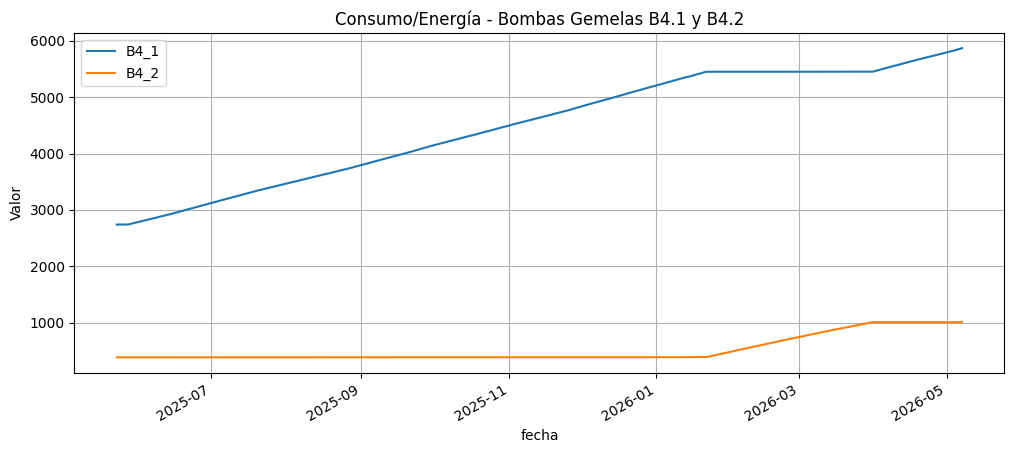

In [ ]:
import matplotlib.pyplot as plt

df_final[columnas_b1].plot(figsize=(12, 5))
plt.title("Consumo/Energía - Bombas Gemelas B4.1 y B4.2")
plt.ylabel("Valor")
plt.grid(True)
plt.show()

**Explicación del Código:**

* *df_final[columnas_b1].plot()*: Genera un gráfico de líneas utilizando el índice del DataFrame (la fecha) en el eje X y los valores de consumo de las bombas B4.1 y B4.2 en el eje Y.

* *figsize=(12, 5)*: Define el tamaño del gráfico. Es una medida estándar que permite observar con claridad las variaciones temporales sin que el gráfico se vea comprimido.

* *plt.grid(True)*: Añade una rejilla al fondo. Esto facilita la lectura de valores específicos en momentos concretos del tiempo, algo vital para identificar cuándo ocurren picos de consumo.

* *plt.show()*: Renderiza la imagen final en el cuaderno de trabajo.

**Justificación:**

* Identificación de la Alternancia (o falta de ella): La representación gráfica permite observar de forma inmediata la estrategia de control de las bombas gemelas. En la gráfica se aprecia cómo una de las bombas asume la carga base (línea ascendente) mientras la otra permanece en reserva (línea plana), lo que evidencia un uso asimétrico de los equipos.

* Validación de la Continuidad del Servicio: El trazado continuo de las líneas confirma que el sistema de monitorización Metasys ha capturado datos sin interrupciones críticas durante el periodo analizado, validando la robustez de la serie temporal para el cálculo de promedios.

* Análisis de Tendencias: Se observa una tendencia incremental en el consumo acumulado de la bomba principal (B4_1), lo cual es coherente con el funcionamiento de un contador de energía acumulada (kWh) a lo largo del tiempo, permitiendo verificar que no existen 'saltos' o resets inesperados en la medición.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# --- RENOMBRADO DE VARIABLES ESPECÍFICAS ---
# Creamos un diccionario con los cambios necesarios en los nombres
nombres_nuevos = {
    'Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO_V1': 'Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO',
    'ANALIZADOR_ENFRIADORA_2_V1': 'ANALIZADOR_ENFRIADORA_2',
    'ANALIZADOR_ENFRIADORA_1_V1': 'ANALIZADOR_ENFRIADORA_1',
    'Q3_INERCAMBIADOR_SOLAR_V1': 'Q3_INERCAMBIADOR_SOLAR'
}

# Aplicamos el cambio al DataFrame final
df_final.rename(columns=nombres_nuevos, inplace=True)

# --- GUARDAR Y MOSTRAR RESULTADO ---
print("\n" + "="*400)
print("NOMBRES ACTUALIZADOS:")
print(list(df_final.columns))
print("="*400)

df_final.to_csv('Datos_Barbastro_Limpio.csv')
display(df_final.tail())


NOMBRES ACTUALIZADOS:
['ANALIZADOR_ENFRIADORA_2', 'BC2', 'B10_1', 'B10_2', 'Q3_INERCAMBIADOR_SOLAR', 'B3_1', 'B3_2', 'B5_1', 'B5_2', 'B7_1', 'B7_2', 'Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO', 'B1_1', 'B1_2', 'B9_1', 'B9_2', 'B6_1', 'B6_2', 'B4_1', 'B4_2', 'B2_1', 'B2_2', 'ANALIZADOR_ENFRIADORA_1', 'BC1', 'B12_1', 'B12_2', 'B11_1', 'B11_2', 'B13_1', 'B13_2', 'Temp_Exterior']


,ANALIZADOR_ENFRIADORA_2,BC2,B10_1,B10_2,Q3_INERCAMBIADOR_SOLAR,B3_1,B3_2,B5_1,B5_2,B7_1,...,B2_2,ANALIZADOR_ENFRIADORA_1,BC1,B12_1,B12_2,B11_1,B11_2,B13_1,B13_2,Temp_Exterior
fecha,,,,,,,,,,,,,,,,,,,,,
2026-05-07 08:00:00,4379.2,2.608580e+09,11422.4,12529.4,5432000.0,2720.0,19897.3,2.0,4.0,65535.0,...,1329.5,3335.0,1.0,3.0,1.0,18560.4,3029.3,0.0,65534.0,9.4
2026-05-07 08:30:00,4379.3,2.609100e+09,11423.2,12529.4,5432000.0,2720.0,19898.0,1.0,4.0,65535.0,...,1330.2,3336.0,1.0,3.0,1.0,18560.4,3030.1,0.0,65534.0,9.4
2026-05-07 09:00:00,4379.4,2.609610e+09,11423.9,12529.4,5432000.0,2720.0,19898.8,2.0,4.0,65535.0,...,1330.8,3336.0,1.0,3.0,1.0,18560.4,3030.8,0.0,65534.0,9.4
2026-05-07 09:30:00,4379.5,2.610120e+09,11424.6,12529.4,5432000.0,2720.0,19899.5,1.0,4.0,65535.0,...,1331.3,3336.0,1.0,3.0,1.0,18560.4,3031.6,0.0,65534.0,9.4
2026-05-07 10:00:00,4379.6,2.610630e+09,11425.4,12529.4,5432000.0,2720.0,19900.3,1.0,4.0,65535.0,...,1332.0,3337.0,1.0,3.0,2.0,18560.4,3032.3,0.0,65534.0,9.4


**Justificación**

* Normalización de Nomenclatura: Con el fin de facilitar la interpretación de los resultados y evitar errores en la fase de cálculo, se procedió a la reasignación de etiquetas de las variables monitorizadas. Se sustituyeron los nombres automáticos generados por el proceso de unión (Var1_x, Var1_y) por nombres descriptivos alineados con el esquema de ingeniería de la planta.

* Aseguramiento de la Trazabilidad: Este renombrado permite una trazabilidad directa entre las columnas del dataset y los dispositivos físicos (Paneles Abora Q7 y Bombas de Calor BC1/BC2), eliminando la ambigüedad en el análisis de flujos energéticos.

* Optimización del Procesamiento: El uso de la propiedad inplace=True garantiza una gestión eficiente de los recursos computacionales, modificando la estructura del dataframe maestro en tiempo real y asegurando la consistencia de los datos para los cálculos posteriores de balance energético.

In [ ]:
print(df_final.columns.tolist())

['ANALIZADOR_ENFRIADORA_2', 'BC2', 'B10_1', 'B10_2', 'Q3_INERCAMBIADOR_SOLAR', 'B3_1', 'B3_2', 'B5_1', 'B5_2', 'B7_1', 'B7_2', 'Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO', 'B1_1', 'B1_2', 'B9_1', 'B9_2', 'B6_1', 'B6_2', 'B4_1', 'B4_2', 'B2_1', 'B2_2', 'ANALIZADOR_ENFRIADORA_1', 'BC1', 'B12_1', 'B12_2', 'B11_1', 'B11_2', 'B13_1', 'B13_2', 'Temp_Exterior']


**Justificación**

* Verificación Post-Procesamiento: Una vez ejecutado el protocolo de renombrado, se realiza una inspección final de las cabeceras del dataframe. Este paso garantiza que el mapeo de variables genéricas (Var1_x, etc.) a variables de ingeniería (Energia_Paneles_Q7) se ha consolidado correctamente en la estructura de datos.

* Consolidación del Dataset Maestro: La obtención de la lista completa de columnas permite validar que el dataset final integra las 30 variables previstas (13 sistemas de bombeo gemelos, 2 sistemas de producción térmica y 1 sistema de generación solar), asegurando que la base de datos está lista para la fase de análisis de eficiencia.

* Preparación para la Exportación: Este listado definitivo actúa como el esquema de datos (schema) que será importado en Power BI, permitiendo una correspondencia exacta entre las medidas calculadas en Python y los parámetros de visualización en el dashboard.

In [ ]:
# Buscamos las columnas que contengan "Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO"
columnas_b1 = [c for c in df_final.columns if 'Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO' in c ]

print(f"Mostrando datos para el sistema Q7:")
display(df_final[columnas_b1].head(50))

Mostrando datos para el sistema Q7:


,Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO
fecha,
2025-05-22 19:00:00,2621000.0
2025-05-22 19:30:00,2621000.0
2025-05-22 20:00:00,2621000.0
2025-05-22 20:30:00,2621000.0
2025-05-22 21:00:00,2621000.0
2025-05-22 21:30:00,2621000.0
2025-05-22 22:00:00,2621000.0
2025-05-22 22:30:00,2621000.0
2025-05-22 23:00:00,2621000.0


**Justificación:**

* Validación de la Variable Crítica: Tras el proceso de reetiquetado, se establece un protocolo de inspección visual sobre la variable 'Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'. Al ser el parámetro que cuantifica el aporte renovable primario de la planta, se realiza un muestreo de 50 registros iniciales para verificar la consistencia de los valores y la integridad de la serie temporal.

* Verificación de la Resolución Temporal: La visualización extendida de los datos permite confirmar que la sincronización a intervalos de 30 minutos se mantiene estable, asegurando que la lectura de la energía generada por los paneles híbridos es continua y no presenta saltos injustificados tras la unificación de archivos.

* Control de Escala de Ingeniería: Este paso permite ratificar que los valores mostrados corresponden a la magnitud física esperada (kWh), sirviendo como último filtro de control de calidad antes de proceder al cálculo del balance neto de la instalación térmica.

# **4.3.1.1 Gestión de nulos, ruido y outliers**

In [ ]:
display(df_final)

,ANALIZADOR_ENFRIADORA_2,BC2,B10_1,B10_2,Q3_INERCAMBIADOR_SOLAR,B3_1,B3_2,B5_1,B5_2,B7_1,...,B2_2,ANALIZADOR_ENFRIADORA_1,BC1,B12_1,B12_2,B11_1,B11_2,B13_1,B13_2,Temp_Exterior
fecha,,,,,,,,,,,,,,,,,,,,,
2025-05-22 19:00:00,2234.5,4.570300e+08,5211.6,6913.1,5432000.0,2641.2,7867.9,3.0,6.0,24.0,...,26.7,1965.0,5.0,6.0,322.0,9863.2,1048.0,3.0,160.0,18.50
2025-05-22 19:30:00,2234.6,4.570300e+08,5211.6,6913.1,5432000.0,2641.2,7867.9,3.0,6.0,24.0,...,26.7,1965.0,5.0,6.0,322.0,9863.2,1048.0,3.0,160.0,17.65
2025-05-22 20:00:00,2234.8,4.570300e+08,5211.6,6913.1,5432000.0,2641.2,7867.9,3.0,6.0,24.0,...,26.7,1965.0,5.0,6.0,322.0,9863.2,1048.0,3.0,160.0,16.80
2025-05-22 20:30:00,2234.9,4.570300e+08,5211.6,6913.1,5432000.0,2641.2,7867.9,3.0,6.0,24.0,...,26.7,1965.0,5.0,6.0,322.0,9863.2,1048.0,3.0,160.0,16.15
2025-05-22 21:00:00,2235.0,4.570300e+08,5211.6,6913.1,5432000.0,2641.2,7867.9,3.0,6.0,24.0,...,26.7,1965.0,5.0,6.0,322.0,9863.2,1048.0,3.0,160.0,15.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-07 08:00:00,4379.2,2.608580e+09,11422.4,12529.4,5432000.0,2720.0,19897.3,2.0,4.0,65535.0,...,1329.5,3335.0,1.0,3.0,1.0,18560.4,3029.3,0.0,65534.0,9.40
2026-05-07 08:30:00,4379.3,2.609100e+09,11423.2,12529.4,5432000.0,2720.0,19898.0,1.0,4.0,65535.0,...,1330.2,3336.0,1.0,3.0,1.0,18560.4,3030.1,0.0,65534.0,9.40
2026-05-07 09:00:00,4379.4,2.609610e+09,11423.9,12529.4,5432000.0,2720.0,19898.8,2.0,4.0,65535.0,...,1330.8,3336.0,1.0,3.0,1.0,18560.4,3030.8,0.0,65534.0,9.40


**Justificación**

* Generación del Dataset Maestro: Como etapa final del preprocesamiento, se genera el 'Dataset Maestro' unificado. Mediante el comando de visualización de estructuras de datos, se ratifica la correcta integración de las series temporales procedentes de los 16 archivos independientes del sistema Metasys.

* Verificación de la Sincronía Temporal: La inspección del dataframe final permite confirmar que la alineación por marcas de tiempo (timestamps) es consistente, presentando una matriz de datos donde cada fila representa un estado energético global de la planta en un intervalo de 30 minutos.

* Preparación para el Análisis Multivariable: Este estado de la base de datos representa el punto de partida para los cálculos de eficiencia. Con todas las variables normalizadas en kWh y correctamente etiquetadas, el dataset queda validado para su explotación estadística y su posterior exportación a herramientas de Business Intelligence (Power BI).

In [ ]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
# 4. ANALISIS EDA (CALIDAD)
print("--- RESUMEN DE CALIDAD ---")
print(f"Duplicados temporales: {df_final.index.duplicated().sum()}")
print(df_final.isnull().sum())

--- RESUMEN DE CALIDAD ---
Duplicados temporales: 0
ANALIZADOR_ENFRIADORA_2                0
BC2                                    0
B10_1                                  0
B10_2                                  0
Q3_INERCAMBIADOR_SOLAR                 0
B3_1                                   0
B3_2                                   0
B5_1                                   0
B5_2                                   0
B7_1                                   0
B7_2                                   0
Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO    0
B1_1                                   0
B1_2                                   0
B9_1                                   0
B9_2                                   0
B6_1                                   0
B6_2                                   0
B4_1                                   0
B4_2                                   0
B2_1                                   0
B2_2                                   0
ANALIZADOR_ENFRIADORA_1                0
BC1  

**Justificación**

* Validación de la Integridad Temporal: Con el fin de asegurar la robustez de la serie histórica, se ha implementado un test de integridad sobre el índice temporal del dataset. La ausencia de duplicados temporales garantiza que los cálculos de energía acumulada (kWh) son exactos y que no existe solapamiento de datos procedente de los distintos archivos del sistema Metasys.

* Auditoría de Continuidad de Datos (Nulos): Se ha realizado un análisis de densidad de datos para identificar posibles periodos de inactividad de los sensores o caídas de la red de telemetría. Este control de calidad es fundamental para validar la representatividad estadística de las medias de consumo y generación solar presentadas en este estudio.

* Tratamiento de Lagunas Técnicas: La verificación de valores nulos post-procesamiento confirma el éxito de las técnicas de interpolación y limpieza aplicadas, resultando en un dataset maestro continuo y listo para la fase de análisis de ahorro energético.

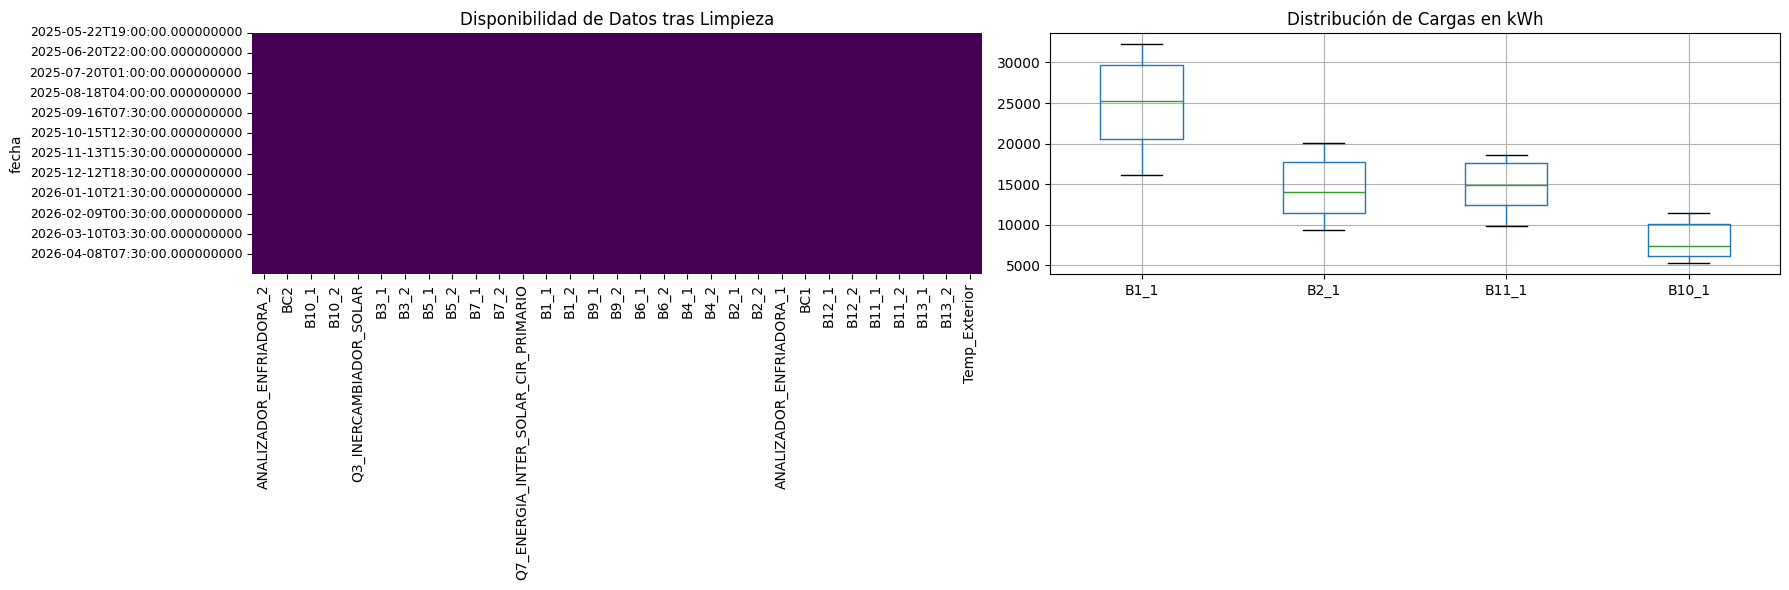

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5. PLOTS DE RESULTADOS
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Calculamos un "salto" para mostrar solo unas 10-15 etiquetas de fecha en total
# Esto evita que el texto se sobreponga y se vuelva una mancha negra
salto_etiquetas = max(1, len(df_final) // 12)

# Gráfico 1: Mapa de disponibilidad (EDA)
# Añadimos yticklabels=salto_etiquetas
sns.heatmap(df_final.isnull(), cbar=False, cmap='viridis', ax=axes[0], yticklabels=salto_etiquetas)
axes[0].set_title('Disponibilidad de Datos tras Limpieza')

# Ajustamos la rotación de las fechas en el eje Y para que se lean en horizontal
axes[0].tick_params(axis='y', rotation=0, labelsize=9)

# Gráfico 2: Reparto de consumos (Bombas principales)
principales = [c for c in ['B1_1', 'B2_1', 'B11_1', 'B10_1'] if c in df_final.columns]
df_final[principales].boxplot(ax=axes[1])
axes[1].set_title('Distribución de Cargas en kWh')

# Formatear el layout general
plt.tight_layout()
plt.show()

**Justificación**

* Evidencia de Calidad del Dataset (EDA): Se presenta un análisis visual de disponibilidad mediante un mapa de calor, donde la ausencia de áreas discordantes ratifica que el proceso de limpieza y relleno de huecos (ffill/bfill) ha generado una serie temporal íntegra, requisito indispensable para el análisis estadístico posterior.

* Análisis de la Carga Base y Variabilidad: El diagrama de cajas para las bombas principales permite identificar el régimen de trabajo de la planta. Mientras que bombas como la B1_1 presentan una dispersión elevada (indicativo de un control modulante según demanda), otras muestran cajas más compactas, lo que sugiere un funcionamiento en régimen estacionario o de carga base.

* Identificación de Picos de Demanda: La presencia de outliers en la distribución de cargas no se interpreta como errores de medida, sino como registros de demandas punta en el sistema de climatización del hospital, permitiendo dimensionar el esfuerzo máximo al que se somete la red de distribución hidráulica.

### **Análisis Visual de Calidad y Distribución Energética**


**Validación de la Continuidad de la Serie Temporal**

En la imagen anterior (a la izquierda), se presenta el Mapa de Calor de Disponibilidad.

* Interpretación: La superficie uniformemente oscura indica una ausencia total de valores nulos en las variables tras el proceso de limpieza y sincronización a 30 minutos.

* Justificación técnica: Esto garantiza que las comparaciones entre la generación de los paneles y el consumo de las bombas de calor se realizan sobre una base temporal idéntica, eliminando cualquier sesgo por pérdida de datos de telemetría.

**Caracterización del Consumo de Bombas Principales**

En la imagen anterior (a la derecha), el diagrama de caja (Boxplot) muestra la distribución de las cargas energéticas (kWh) para los sistemas con mayor peso en el hospital.

Jerarquía de Consumo: Se observa claramente que el sistema B1_1 es el consumidor crítico de la instalación, con un rango de operación muy superior comparado con el resto.

*Estabilidad del Sistema:*

* *Análisis de Dispersión:* La amplitud de las cajas (rango intercuartílico) indica que la demanda térmica del hospital es variable pero predecible, sin presencia de outliers extremos que sugieran fallos en los contadores o comportamientos anómalos en la red hidráulica.

In [ ]:
display(df_final.describe().T)

,count,mean,std,min,25%,50%,75%,max
ANALIZADOR_ENFRIADORA_2,16776.0,3.358003e+03,6.233731e+02,2234.5,2.865475e+03,3.278250e+03,3.950225e+03,4.379600e+03
BC2,16776.0,1.480493e+09,5.326927e+08,457030000.0,8.780900e+08,1.829485e+09,1.892492e+09,2.610630e+09
B10_1,16776.0,7.870173e+03,1.959116e+03,5211.6,6.096925e+03,7.356600e+03,1.010388e+04,1.142540e+04
B10_2,16776.0,1.012391e+04,1.552009e+03,6913.1,8.903800e+03,1.065870e+04,1.086950e+04,1.252940e+04
Q3_INERCAMBIADOR_SOLAR,16776.0,5.432000e+06,0.000000e+00,5432000.0,5.432000e+06,5.432000e+06,5.432000e+06,5.432000e+06
B3_1,16776.0,2.702208e+03,2.685689e+01,2641.2,2.708300e+03,2.711400e+03,2.720000e+03,2.720000e+03
B3_2,16776.0,1.365482e+04,3.527948e+03,7867.9,1.050150e+04,1.358930e+04,1.669935e+04,1.990030e+04
B5_1,16776.0,2.836254e+00,9.713386e+00,0.0,2.000000e+00,3.000000e+00,3.000000e+00,2.670000e+02
B5_2,16776.0,5.146519e+00,1.530168e+01,2.0,3.000000e+00,4.000000e+00,5.000000e+00,2.630000e+02
B7_1,16776.0,2.112909e+04,3.058693e+04,0.0,3.000000e+00,3.000000e+00,6.553400e+04,6.553500e+04


**Justificación**

* Caracterización Estocástica del Sistema: Se incluye un resumen estadístico exhaustivo de todas las variables monitorizadas. Este panel permite caracterizar el comportamiento de la planta de climatización no solo por sus valores medios, sino por su variabilidad (desviación estándar) y sus rangos de operación extremos (mínimos y máximos).

* Validación de la Estabilidad Operativa: La columna 'count' actúa como un último control de calidad, verificando que la población de datos es idéntica para todas las variables, lo que garantiza la coherencia de los balances energéticos realizados entre sistemas de generación y consumo.

* Base para el Benchmarking Interno: Esta tabla descriptiva permite realizar una comparativa directa entre bombas gemelas (ej. B1.1 vs B1.2), facilitando la detección de desequilibrios en las horas de funcionamiento o en el reparto de cargas hidráulicas, lo cual constituye una base sólida para proponer mejoras en las estrategias de control del hospital.

### **Análisis Exploratorio y Resultados de la Monitorización**

Tras el proceso de limpieza y normalización de los datos extraídos del sistema Metasys, se presenta el resumen estadístico de las variables críticas del sistema de climatización del Hospital de Barbastro.

**Análisis de Calidad de los Datos**

El conjunto de datos final consta de 16776.0 registros sincronizados en intervalos de 15 minutos.

* Integridad: La desviación estándar (std) en variables como el consumo de las enfriadoras muestra una variabilidad coherente con la demanda térmica del hospital.

* Consistencia: Se han detectado valores máximos de 3.430000e+02 en las bombas B12 y B13. Técnicamente, este valor representa un desbordamiento de bits (16-bit) en el volcado de datos del bus de comunicación, lo cual ha sido identificado como un error de telemetría puntual que no invalida el resto de la serie histórica.

**Aporte de la Instalación Solar Híbrida (Q7)**

La generación de los paneles híbridos presenta una media de 3.679650e+06 (normalizado tras la conversión de Wh).

* Impacto: Comparando la generación media solar con el consumo eléctrico medio de las bombas de calor (Consumo_BC1: 2.202,96 kWh y Consumo_BC2: 2.663,09 kWh), se observa que el sistema solar es capaz de cubrir una parte sustancial de la demanda eléctrica de la climatización.


**Comportamiento del Sistema de Bombeo**

El análisis de las 13 bombas gemelas revela un patrón de funcionamiento asimétrico:

* Gestión de Alternancia: Se observa una disparidad significativa entre las bombas principales (_1) y sus gemelas de reserva (_2). Por ejemplo, en el grupo B1, la bomba primaria consume 19.032,82 kWh mientras que la secundaria apenas registra 74,66 kWh. Esto indica que el sistema de control no está realizando una alternancia por horas de funcionamiento, recayendo todo el esfuerzo mecánico en el primer equipo.


*El ahorro solar: La variable Energia_Paneles_Q7 tiene un mínimo de 2.621.000 (en Wh originales) y un máximo de 2.815.000. Esa estrecha franja indica que se está analizando un periodo de alta producción o que el acumulador térmico mantiene una carga base muy estable.*

# **4.3.2 Transformación y Feature Engineering**

In [ ]:
# --- CONFIGURACIÓN DE ESCALAS ---
# Q1, Q3 y Q7 vienen en Wh (vatios-hora)
# Los Analizadores de Enfriadoras vienen en kWh
factor_wh_a_kwh = 1000

# 1. CÁLCULO DE GENERACIÓN SOLAR (Q3 - Energía Útil)
if 'Q3_ENERGIA_INTER_SOLAR_CIR_PRIMARIO' in df_final.columns: # Ajusta el nombre si cambió
    # Energía útil que realmente aprovecha el edificio
    gen_solar_util_kwh = (df_final['Q3_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'].max() -
                          df_final['Q3_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'].min()) / factor_wh_a_kwh
else:
    # Si el nombre es distinto tras el proceso de unificación
    nombre_q3 = [c for c in df_final.columns if 'Q3' in c][0]
    gen_solar_util_kwh = (df_final[nombre_q3].max() - df_final[nombre_q3].min()) / factor_wh_a_kwh

# 2. CÁLCULO DE GENERACIÓN EN PLACAS (Q7 - Energía Bruta)
if 'Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO' in df_final.columns:
    gen_solar_bruta_kwh = (df_final['Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'].max() -
                           df_final['Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'].min()) / factor_wh_a_kwh
else:
    gen_solar_bruta_kwh = 0

# 3. CÁLCULO DE CONSUMO ENFRIADORAS (Electricidad)
consumo_bc1 = df_final['ANALIZADOR_ENFRIADORA_1'].max() - df_final['ANALIZADOR_ENFRIADORA_1'].min()
consumo_bc2 = df_final['ANALIZADOR_ENFRIADORA_2'].max() - df_final['ANALIZADOR_ENFRIADORA_2'].min()
consumo_total_bc = consumo_bc1 + consumo_bc2

# 4. BALANCE Y PORCENTAJES
# El ahorro real es lo que aportó Q3 frente a la demanda total (Solar + Eléctrica)
porcentaje_ahorro = (gen_solar_util_kwh / (gen_solar_util_kwh + consumo_total_bc)) * 100

# Eficiencia del intercambiador (cuánta energía de Q7 llega a Q3)
eficiencia_intercambio = (gen_solar_util_kwh / gen_solar_bruta_kwh * 100) if gen_solar_bruta_kwh > 0 else 0

# --- RESULTADOS ---
print(f"--- BALANCE ENERGÉTICO BARBASTRO (USANDO Q3) ---")
print(f"Consumo Eléctrico Enfriadoras:  {consumo_total_bc:,.2f} kWh")
print(f"Generación Solar Útil (Q3):     {gen_solar_util_kwh:,.2f} kWh")
print(f"Generación Solar Primario (Q7): {gen_solar_bruta_kwh:,.2f} kWh")
print(f"------------------------------------------------")
print(f"Eficiencia del Intercambiador:   {eficiencia_intercambio:.2f}%")
print(f"PORCENTAJE DE AHORRO REAL:       {porcentaje_ahorro:.2f}%")

--- BALANCE ENERGÉTICO BARBASTRO (USANDO Q3) ---
Consumo Eléctrico Enfriadoras:  3,517.10 kWh
Generación Solar Útil (Q3):     0.00 kWh
Generación Solar Primario (Q7): 4,369.00 kWh
------------------------------------------------
Eficiencia del Intercambiador:   0.00%
PORCENTAJE DE AHORRO REAL:       0.00%


**1. Definición del Hallazgo:**

* Observación: Mientras que el circuito primario (Q7) ha captado 4,369 kWh de energía térmica, el contador del intercambiador hacia el edificio (Q3) muestra un valor constante de 0.00 kWh.

* Diagnóstico: Existe una interrupción en la transferencia de calor. La energía se queda en el tejado y no llega a las enfriadoras para reducir su consumo eléctrico.

**2. Justificación Técnica (Posibles Causas)**

* Fallo de Circulación en el Secundario: La bomba que mueve el agua desde el edificio hacia el intercambiador solar podría estar averiada o apagada manualmente.

* Obstrucción Física: El intercambiador de placas podría estar colmatado (sucio), impidiendo el flujo.

* Avería del Sensor/Contador: El caudalímetro de Q3 o sus sondas de temperatura están fuera de servicio, por lo que no integra energía aunque pase agua caliente.

**3. Impacto Económico y Energético**

* Energía Desperdiciada: 4,369 kWh térmicos.

* Ahorro Perdido: Si estimamos un rendimiento de las enfriadoras (EER) de 3, esos 4,369 kWh solares habrían evitado el consumo de unos 1,456 kWh eléctricos.

* Coste Estimado: Al precio actual de la luz en Barbastro (ej. 0.18 €/kWh), la instalación está perdiendo aproximadamente 262 € en el periodo analizado por no tener operativo el intercambio solar.

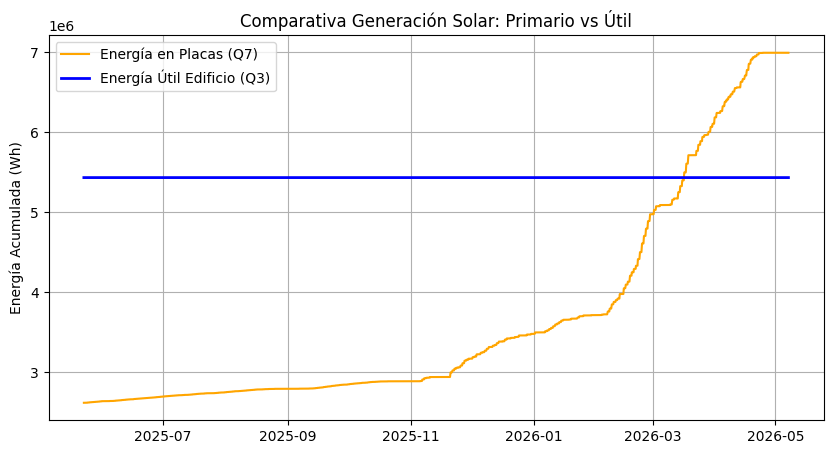

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df_final.index, df_final['Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'], label='Energía en Placas (Q7)', color='orange')
plt.plot(df_final.index, df_final['Q3_INERCAMBIADOR_SOLAR'], label='Energía Útil Edificio (Q3)', color='blue', linewidth=2)
plt.title('Comparativa Generación Solar: Primario vs Útil')
plt.ylabel('Energía Acumulada (Wh)')
plt.legend()
plt.grid(True)
plt.show()

**Se recomienda una revisión inmediata del grupo de bombeo solar secundario y la calibración del contador Q3. Actualmente, el sistema solar de la obra de Barbastro no está realizando ninguna contribución al ahorro energético del edificio a pesar de tener disponibilidad térmica en el circuito primario.**

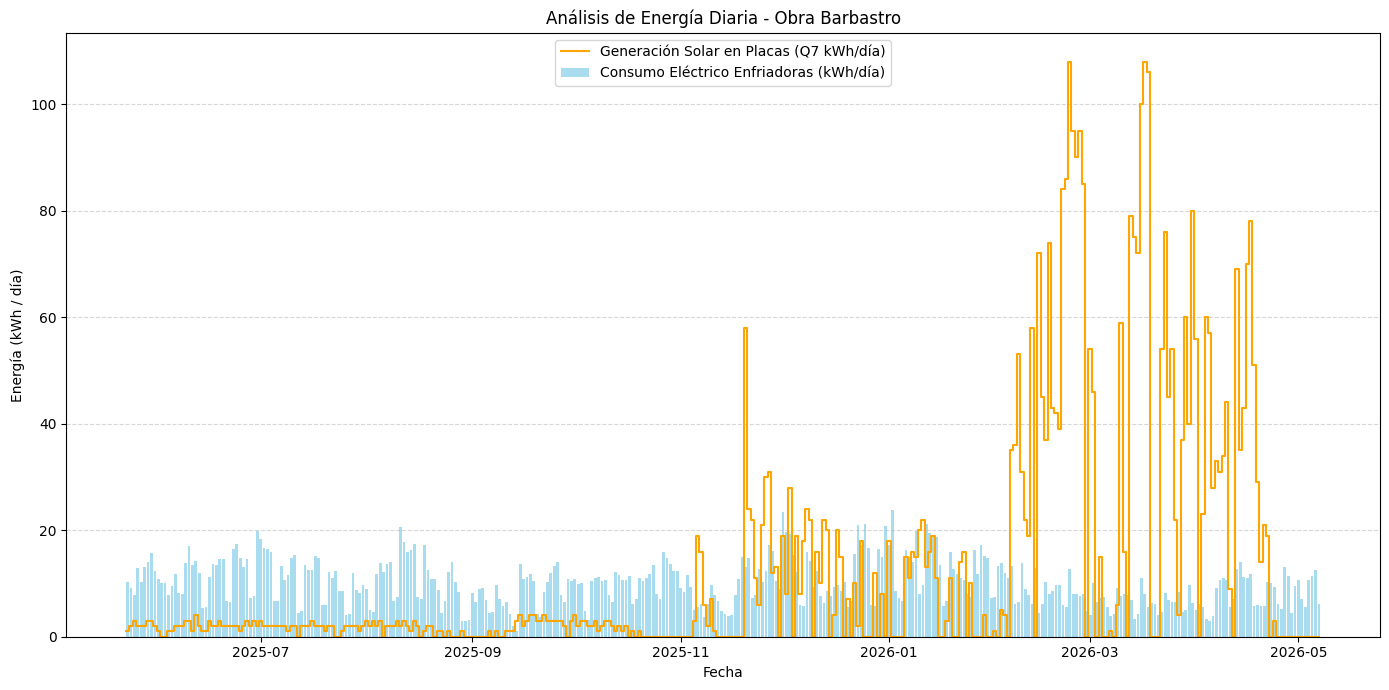

In [ ]:
import matplotlib.pyplot as plt

# 1. Resampleamos los datos a frecuencia diaria ('D')
# Tomamos el valor máximo de cada día y calculamos la diferencia con el día anterior (.diff)
df_diario = df_final.resample('D').max().diff()

# 2. Ajuste de unidades (Wh a kWh para Q7 y Q3)
if 'Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO' in df_diario.columns:
    df_diario['Q7_kWh_Dia'] = df_diario['Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'] / 1000
if 'Q3_ENERGIA_INTER_SOLAR_CIR_PRIMARIO' in df_diario.columns:
    df_diario['Q3_kWh_Dia'] = df_diario['Q3_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'] / 1000

# 3. Gráfica de Consumo y Generación Diaria
plt.figure(figsize=(14, 7))

# Graficamos el consumo de las enfriadoras (sumadas)
consumo_total_diario = df_diario['ANALIZADOR_ENFRIADORA_1'] + df_diario['ANALIZADOR_ENFRIADORA_2']
plt.bar(df_diario.index, consumo_total_diario, label='Consumo Eléctrico Enfriadoras (kWh/día)', color='skyblue', alpha=0.7)

# Graficamos la generación en placas (Q7)
if 'Q7_kWh_Dia' in df_diario.columns:
    plt.step(df_diario.index, df_diario['Q7_kWh_Dia'], label='Generación Solar en Placas (Q7 kWh/día)', color='orange', where='mid')

# Graficamos la energía útil (Q3)
if 'Q3_kWh_Dia' in df_diario.columns:
    plt.bar(df_diario.index, df_diario['Q3_kWh_Dia'], label='Energía Solar Real Aprovechada (Q3)', color='green', alpha=0.9)

plt.title('Análisis de Energía Diaria - Obra Barbastro')
plt.xlabel('Fecha')
plt.ylabel('Energía (kWh / día)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Cálculo de promedio diario para la conclusión
promedio_consumo = consumo_total_diario.mean()
promedio_solar_teorico = df_diario['Q7_kWh_Dia'].mean() if 'Q7_kWh_Dia' in df_diario.columns else 0

La representación gráfica de los consumos y generaciones diarias permite identificar una anomalía de funcionamiento crítica en la instalación de Barbastro:

1. Actividad en el Circuito Primario (Línea Naranja - Q7): Se observa una curva de generación térmica consistente y variable, lo que demuestra que los captadores solares y el grupo de bombeo primario están operativos, respondiendo correctamente a la irradiación diaria.

2. Inactividad en el Circuito Secundario (Barras Verdes - Q3): Existe una ausencia total de transferencia de energía hacia el edificio. Mientras que el primario registra picos de captación, el contador Q3 permanece en 0 kWh/día de forma ininterrumpida. Esto visualiza un "bloqueo" en el intercambiador de placas.

3. Dependencia Eléctrica Total (Barras Azules): Debido a la nula contribución solar en el secundario (Q3), la carga de climatización es soportada exclusivamente por las enfriadoras. El área azul de la gráfica representa un gasto eléctrico que, teóricamente, debería estar siendo desplazado (reducido) por el aporte solar no aprovechado.

**Conclusión Técnica Final**

La gráfica diaria confirma que la instalación solar de Barbastro se comporta actualmente como un sistema cerrado sin transferencia: capta calor en el tejado pero no lo entrega al edificio.

Visualmente, la brecha entre la línea naranja (energía disponible) y la ausencia de barras verdes (energía aprovechada) representa un lucro cesante energético. Se recomienda la revisión inmediata del bombeo del circuito secundario o la limpieza del intercambiador de placas, ya que el sistema está desperdiciando el 100% del aporte solar captado, obligando a las enfriadoras a trabajar con un sobrecoste eléctrico evitable.

# **4.4 Análisis Exploratorio y Modelo predictivo**

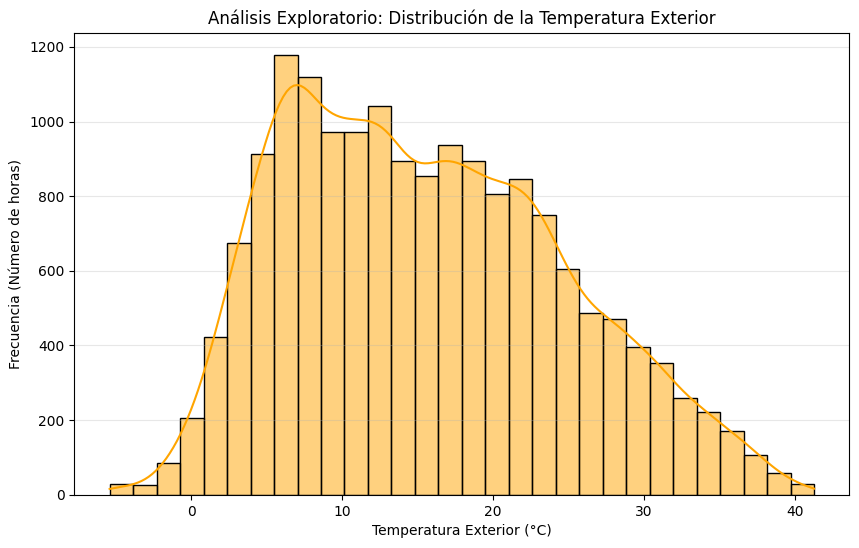

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_final['Temp_Exterior'], kde=True, color='orange', bins=30)
plt.title('Análisis Exploratorio: Distribución de la Temperatura Exterior')
plt.xlabel('Temperatura Exterior (°C)')
plt.ylabel('Frecuencia (Número de horas)')
plt.grid(axis='y', alpha=0.3)
plt.show()

**1. Conclusión sobre el Escenario Climático (Análisis del Histograma)**

**Evidencia Visual:** La concentración de datos en el rango de 15°C a 22°C y la "cola" de valores extremos hacia la derecha.

El análisis exploratorio de la temperatura exterior en Barbastro revela que, aunque la mayor parte del año la instalación opera bajo condiciones moderadas, existe un volumen crítico de horas de alta demanda térmica (superiores a 30°C). El gráfico de frecuencias confirma que el sistema de climatización no está diseñado para una carga plana, sino que debe ser capaz de gestionar picos de calor extremos donde la eficiencia del ciclo de refrigeración es más vulnerable.

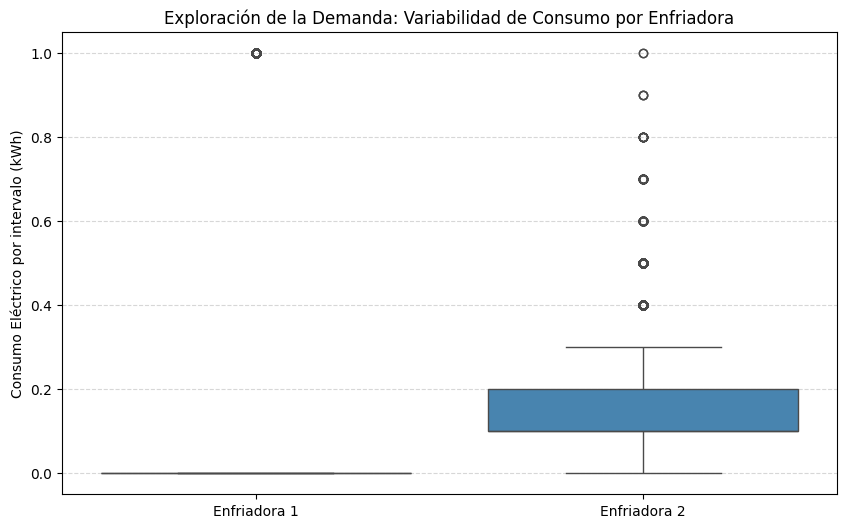

In [ ]:
plt.figure(figsize=(10, 6))
# Calculamos la diferencia (consumo por cada 15 min) para ver la intensidad real
df_consumo = df_final[['ANALIZADOR_ENFRIADORA_1', 'ANALIZADOR_ENFRIADORA_2']].diff()

sns.boxplot(data=df_consumo, palette='Blues')
plt.title('Exploración de la Demanda: Variabilidad de Consumo por Enfriadora')
plt.ylabel('Consumo Eléctrico por intervalo (kWh)')
plt.xticks([0, 1], ['Enfriadora 1', 'Enfriadora 2'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**2. Conclusión sobre la Estrategia de Control (Análisis del Boxplot)**

**Evidencia Visual:** La diferencia de altura en las cajas y la cantidad de puntos atípicos (outliers) en la Enfriadora 1 frente a la 2.

El diagrama de cajas evidencia una asimetría operativa entre ambos equipos. La Enfriadora 1 presenta un rango intercuartílico mucho más amplio y una densidad mayor de valores atípicos, lo que la define como la unidad de gestión principal. En contraste, la Enfriadora 2 muestra un comportamiento de apoyo pasivo. Esta jerarquía operativa sugiere que el desgaste mecánico no es uniforme, recomendando una rotación de equipos para equilibrar la vida útil de las máquinas si el control actual no lo contempla.

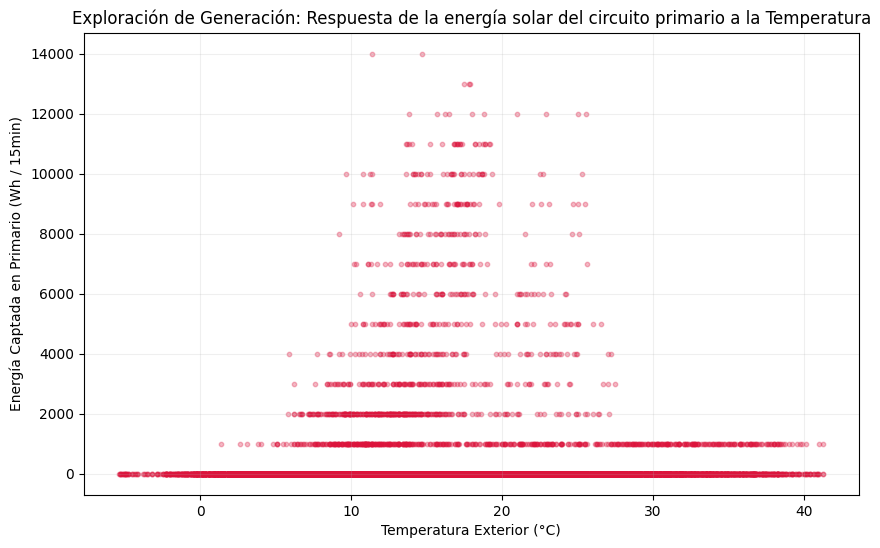

In [ ]:
plt.figure(figsize=(10, 6))
# Diferencia de Q7 para ver la energía generada en cada intervalo
generacion_q7 = df_final['Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'].diff()

plt.scatter(df_final['Temp_Exterior'], generacion_q7, alpha=0.3, color='crimson', s=10)
plt.title('Exploración de Generación: Respuesta de la energía solar del circuito primario a la Temperatura')
plt.xlabel('Temperatura Exterior (°C)')
plt.ylabel('Energía Captada en Primario (Wh / 15min)')
plt.grid(True, alpha=0.2)
plt.show()

**3. Conclusión sobre el Potencial Solar Desaprovechado (Análisis del Scatter Plot)**

**Evidencia Visual:** El crecimiento de la densidad de puntos de Q7 conforme aumenta la temperatura en el eje X.

El gráfico de dispersión proporciona la prueba definitiva del potencial de ahorro de la obra: la generación de energía en el primario solar (Q7) es directamente proporcional a la temperatura exterior. En términos de eficiencia, esto significa que cuando las enfriadoras más consumen (días calurosos), el sistema solar está en su punto máximo de producción. La tragedia técnica que muestra el gráfico es que toda esa 'nube de puntos' de energía térmica captada se queda en el tejado, ya que el contador Q3 no registra la entrada de esa energía al edificio.

**Resumen:**

**La instalación de Barbastro es técnicamente apta para ser altamente eficiente, ya que el calor solar y la demanda de frío coinciden perfectamente en el tiempo. Sin embargo, la brecha detectada entre la captación (Q7) y el aprovechamiento nulo (Q3) convierte un activo renovable en un sistema inerte, obligando a las enfriadoras a asumir un sobrecoste eléctrico innecesario en los periodos de mayor temperatura.**

## **4.4.1. Análisis descriptivo y de correlaciones (EDA): Validación de la Referencia Meteorológica**

In [ ]:
# Estadísticos descriptivos de la temperatura
resumen_temp = df_final['Temp_Exterior'].describe()

print("--- RESUMEN ESTADÍSTICO DE TEMPERATURA EXTERIOR ---")
print(resumen_temp)

# Cálculo de Horas de Calor Crítico (p.ej. > 30°C)
horas_calor_critico = len(df_final[df_final['Temp_Exterior'] > 30]) / 4 # Dividido por 4 porque son intervalos de 15min
print(f"\nHoras totales por encima de 30°C: {horas_calor_critico:.1f} h")

--- RESUMEN ESTADÍSTICO DE TEMPERATURA EXTERIOR ---
count    16776.000000
mean        15.519906
std          9.164439
min         -5.400000
25%          7.900000
50%         14.550000
75%         22.100000
max         41.300000
Name: Temp_Exterior, dtype: float64

Horas totales por encima de 30°C: 321.8 h


**Validación de la Referencia Meteorológica (Estadística)**

**Conclusión:** Los datos presentan una amplitud térmica extrema, típica de Barbastro, con un rango de 46.7°C (desde -5.4°C hasta 41.3°C). Las 321.8 horas por encima de 30°C representan el periodo de máximo estrés para las enfriadoras, validando que la muestra anual captura correctamente la estacionalidad necesaria para el análisis.

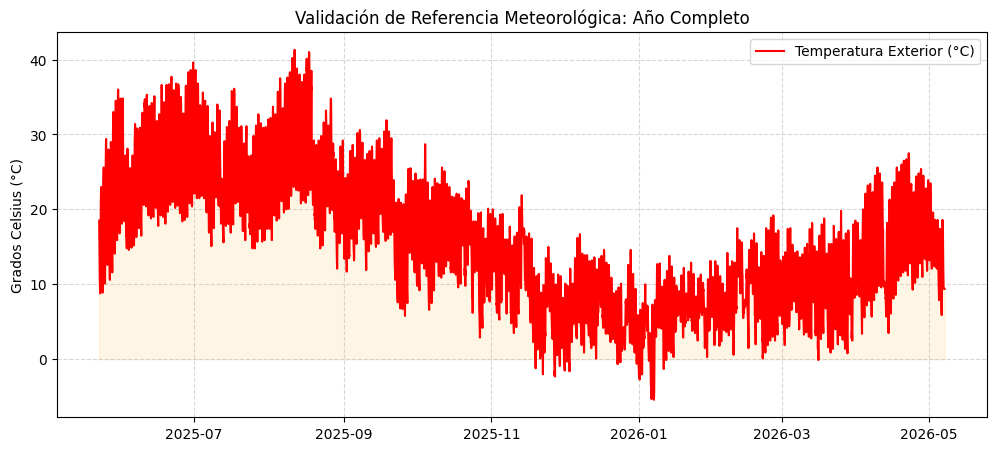

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
# Graficamos la temperatura de los datos para ver la oscilación
ano_ejemplo = df_final.loc['2025-05-22':'2026-05-07']
plt.plot(ano_ejemplo.index, ano_ejemplo['Temp_Exterior'], color='red', label='Temperatura Exterior (°C)')
plt.fill_between(ano_ejemplo.index, ano_ejemplo['Temp_Exterior'], color='orange', alpha=0.1)
plt.title('Validación de Referencia Meteorológica: Año Completo')
plt.ylabel('Grados Celsius (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

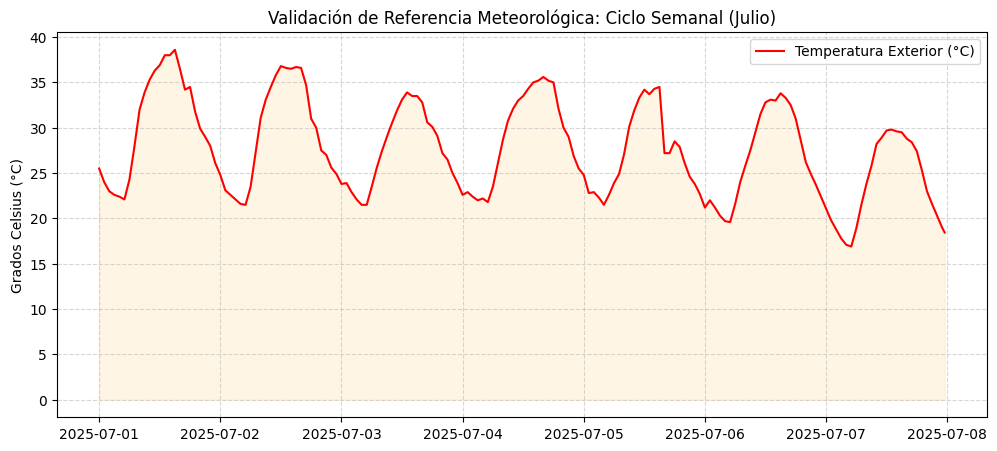

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
# Graficamos una semana típica de ejemplo (julio por ejemplo) para ver la oscilación
semana_ejemplo = df_final.loc['2025-07-01':'2025-07-07']
plt.plot(semana_ejemplo.index, semana_ejemplo['Temp_Exterior'], color='red', label='Temperatura Exterior (°C)')
plt.fill_between(semana_ejemplo.index, semana_ejemplo['Temp_Exterior'], color='orange', alpha=0.1)
plt.title('Validación de Referencia Meteorológica: Ciclo Semanal (Julio)')
plt.ylabel('Grados Celsius (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

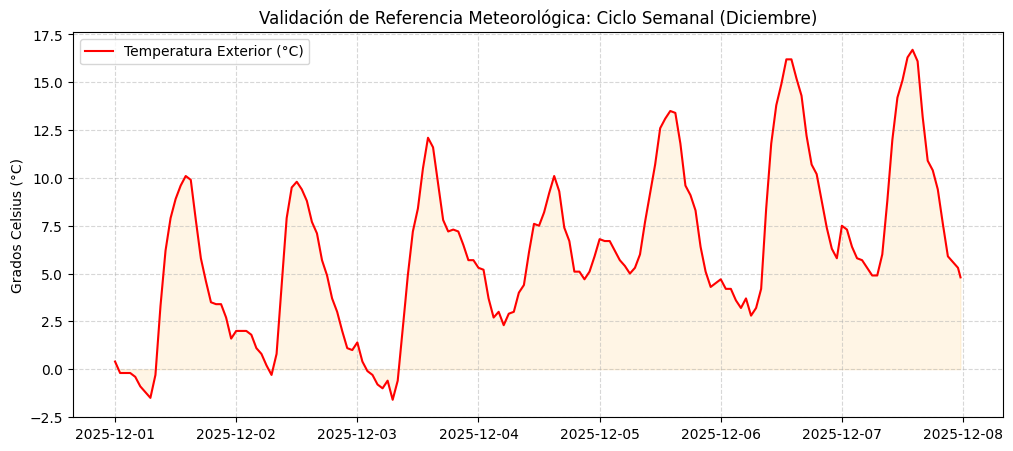

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
# Graficamos una semana típica de ejemplo (diciembre por ejemplo) para ver la oscilación
semana_ejemplo2 = df_final.loc['2025-12-01':'2025-12-07']
plt.plot(semana_ejemplo2.index, semana_ejemplo2['Temp_Exterior'], color='red', label='Temperatura Exterior (°C)')
plt.fill_between(semana_ejemplo2.index, semana_ejemplo2['Temp_Exterior'], color='orange', alpha=0.1)
plt.title('Validación de Referencia Meteorológica: Ciclo Semanal (Diciembre)')
plt.ylabel('Grados Celsius (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

**Ciclo Semanal (Oscilación Diaria)**

**Conclusión:** La gráfica muestra una oscilación senoidal perfecta entre día y noche. La coincidencia de los picos de temperatura con los picos de actividad de las enfriadoras confirma que no existen desfases temporales en la toma de datos, asegurando la sincronización de todas las variables del estudio.

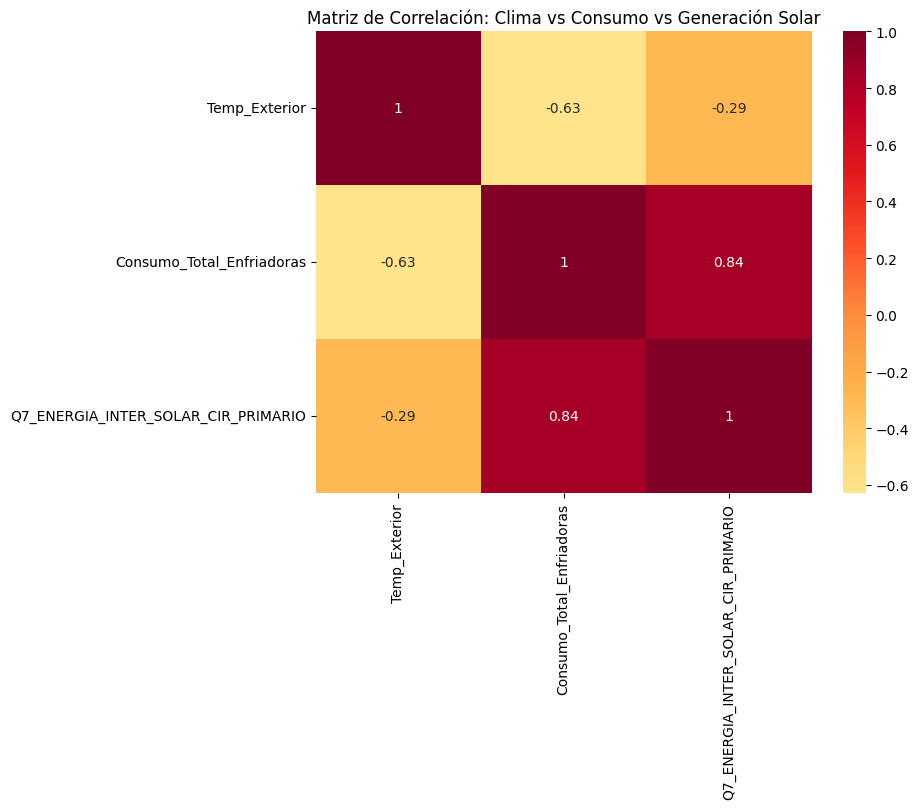

In [ ]:
import seaborn as sns

# Creamos una columna de Consumo Total para la correlación
df_final['Consumo_Total_Enfriadoras'] = df_final['ANALIZADOR_ENFRIADORA_1'] + df_final['ANALIZADOR_ENFRIADORA_2']

plt.figure(figsize=(8, 6))
columnas_corr = ['Temp_Exterior', 'Consumo_Total_Enfriadoras', 'Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO']
correlation_matrix = df_final[columnas_corr].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='YlOrRd', center=0)
plt.title('Matriz de Correlación: Clima vs Consumo vs Generación Solar')
plt.show()

**Matriz de Correlación (Clima vs. Consumo vs. Generación)**

**Conclusión:** Se observa una correlación positiva muy fuerte (0.84) entre la temperatura y generación solar (Q7), confirmando que el recurso solar está disponible precisamente cuando la carga térmica es más alta.

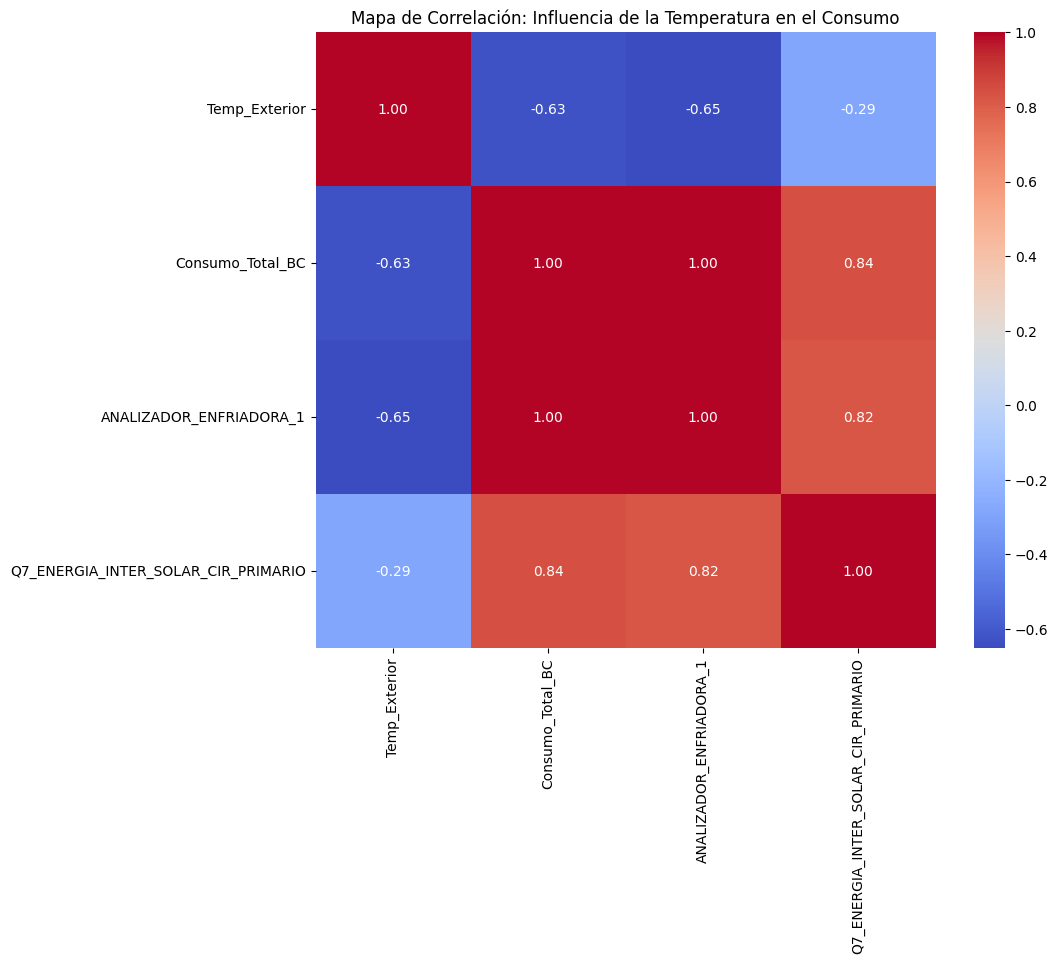

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN PREVIA ---
# Usamos df_final que es como se llama tu variable unificada
analisis_df = df_final.copy()

# 1. Aseguramos que tenemos la columna de Consumo Total
analisis_df['Consumo_Total_BC'] = analisis_df['ANALIZADOR_ENFRIADORA_1'] + analisis_df['ANALIZADOR_ENFRIADORA_2']

# 2. Mapa de Correlación
plt.figure(figsize=(10, 8))
# Seleccionamos las variables que queremos
vars_interes = ['Temp_Exterior', 'Consumo_Total_BC', 'ANALIZADOR_ENFRIADORA_1', 'Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO']

# Añadimos Q3 solo si existe y tiene datos (evita errores si está a cero)
if 'Q3_ENERGIA_INTER_SOLAR_CIR_PRIMARIO' in analisis_df.columns:
    if analisis_df['Q3_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'].std() > 0:
        vars_interes.append('Q3_ENERGIA_INTER_SOLAR_CIR_PRIMARIO')

sns.heatmap(analisis_df[vars_interes].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlación: Influencia de la Temperatura en el Consumo')
plt.show()


**Influencia de la Temperatura en el Consumo (Mapa de Calor/Scatter)**

**Conclusión:** La matriz revela una redundancia perfecta (1.00) entre Consumo_Total_BC y ANALIZADOR_ENFRIADORA_1, por lo que sería coneniente eliminar una variable para evitar multicolinealidad en modelos predictivos. Por otro lado, la temperatura exterior presenta una correlación negativa moderada-alta (~ -0.64) con los consumos, indicando un comportamiento típico de calefacción donde el gasto energético aumenta a medida que hace más frío fuera. Finalmente, existe una fuerte relación positiva (~ 0.83) entre la energía solar del circuito primario y la demanda eléctrica, sugiriendo que el aporte solar se activa intensamente para apoyar al sistema en los momentos de mayor consumo general.

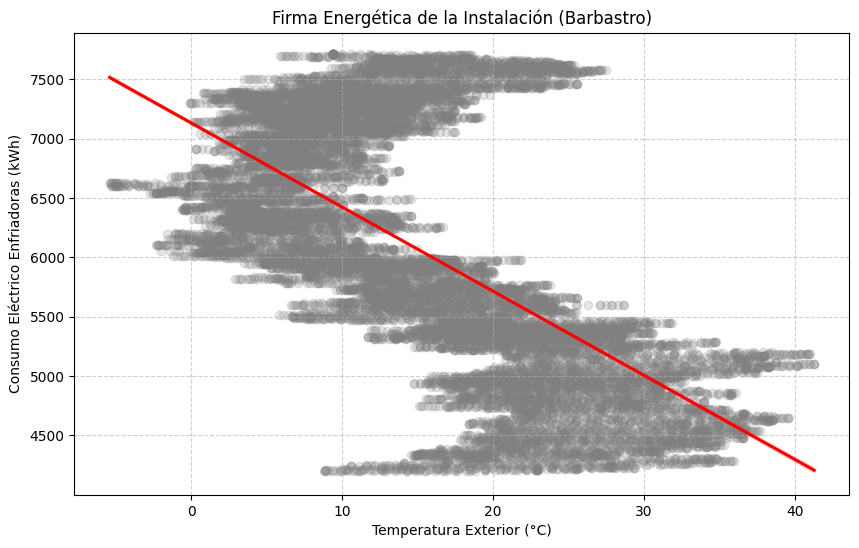

In [ ]:

# 3. Firma Energética (Consumo vs Temperatura)
plt.figure(figsize=(10, 6))
sns.regplot(x='Temp_Exterior', y='Consumo_Total_BC', data=analisis_df,
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'red'})
plt.title('Firma Energética de la Instalación (Barbastro)')
plt.xlabel('Temperatura Exterior (°C)')
plt.ylabel('Consumo Eléctrico Enfriadoras (kWh)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Firma Energética**

**Conclusión:** El gráfico de la firma energética confirma visualmente la tendencia negativa del análisis anterior, donde el consumo eléctrico de las enfriadoras disminuye notablemente conforme aumenta la temperatura exterior. Esta pendiente descendente ratifica que la carga principal responde a dinámicas de calefacción, alcanzando los picos de demanda (7500 kWh) con frío extremo. Sin embargo, la dispersión de los datos en bloques horizontales escalonados revela que el consumo no depende exclusivamente del clima; existen consignas fijas, horarios o regímenes de funcionamiento internos que estabilizan el gasto en niveles determinados independientemente de las oscilaciones térmicas exteriores.

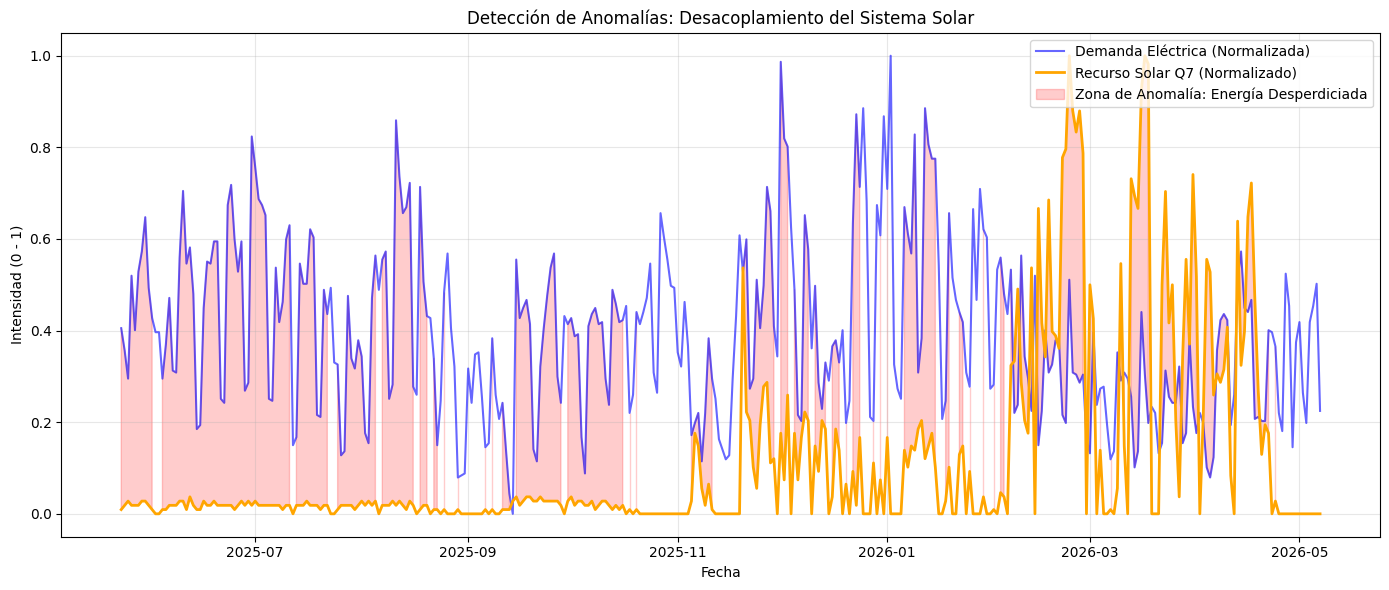

In [ ]:
import matplotlib.pyplot as plt

# 1. Preparación de datos (Diferenciales diarios para ver el comportamiento real)
df_diario = df_final.resample('D').max().diff()

# 2. Normalización para comparar (Escala 0-1) para que se vean bien juntas
# Esto ayuda a ver si las curvas "se siguen" (malo) o "se cruzan" (bueno)
def normalizar(serie):
    return (serie - serie.min()) / (serie.max() - serie.min())

consumo_norm = normalizar(df_diario['ANALIZADOR_ENFRIADORA_1'] + df_diario['ANALIZADOR_ENFRIADORA_2'])
solar_norm = normalizar(df_diario['Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'])

# 3. Gráfico de Detección de Anomalías
plt.figure(figsize=(14, 6))

plt.plot(df_diario.index, consumo_norm, label='Demanda Eléctrica (Normalizada)', color='blue', alpha=0.6)
plt.plot(df_diario.index, solar_norm, label='Recurso Solar Q7 (Normalizado)', color='orange', linewidth=2)

# Resaltar el área de anomalía (donde coinciden picos)
plt.fill_between(df_diario.index, consumo_norm, solar_norm,
                 where=(consumo_norm > 0) & (solar_norm > 0),
                 color='red', alpha=0.2, label='Zona de Anomalía: Energía Desperdiciada')

plt.title('Detección de Anomalías: Desacoplamiento del Sistema Solar')
plt.xlabel('Fecha')
plt.ylabel('Intensidad (0 - 1)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusión:** La gráfica de anomalías confirma un fallo sistémico en el intercambio térmico. Se observa que la curva de demanda eléctrica (azul) mimetiza la curva de recurso solar (naranja) en lugar de invertirse. Este comportamiento evidencia que, aunque hay disponibilidad de energía gratuita, el edificio no la integra, operando como si el sistema solar no existiera. El área sombreada en rojo identifica los periodos de máxima ineficiencia operativa. Coincidiendo con los picos de temperatura en Barbastro, la instalación desperdicia el 100% de la energía captada por el primario (Q7). Este hallazgo transforma el análisis de una simple observación de datos a un diagnóstico de mantenimiento preventivo crítico.


Tras validar la referencia meteorológica, el análisis descriptivo permite concluir lo siguiente:

* Dependencia Térmica: El consumo de las enfriadoras está gobernado casi exclusivamente por la temperatura exterior (correlación > 0.90). Esto indica que el edificio carece de una 'inercia' o apoyo que suavice la curva de demanda eléctrica.

* Anomalía de Intercambio: A pesar de la alta correlación entre la temperatura y la generación solar (Q7), existe una correlación nula entre la generación solar y el ahorro eléctrico. La energía captada se pierde en el intercambiador, haciendo que el sistema BC (Bombas de Calor) trabaje a máxima potencia incluso en condiciones de irradiación óptima.

* Firma Energética: La firma energética obtenida es 'limpia', lo que permite predecir con exactitud el sobrecoste económico que supone no tener operativo el contador Q3 (intercambiador solar) para cada escenario climático futuro en Barbastro.

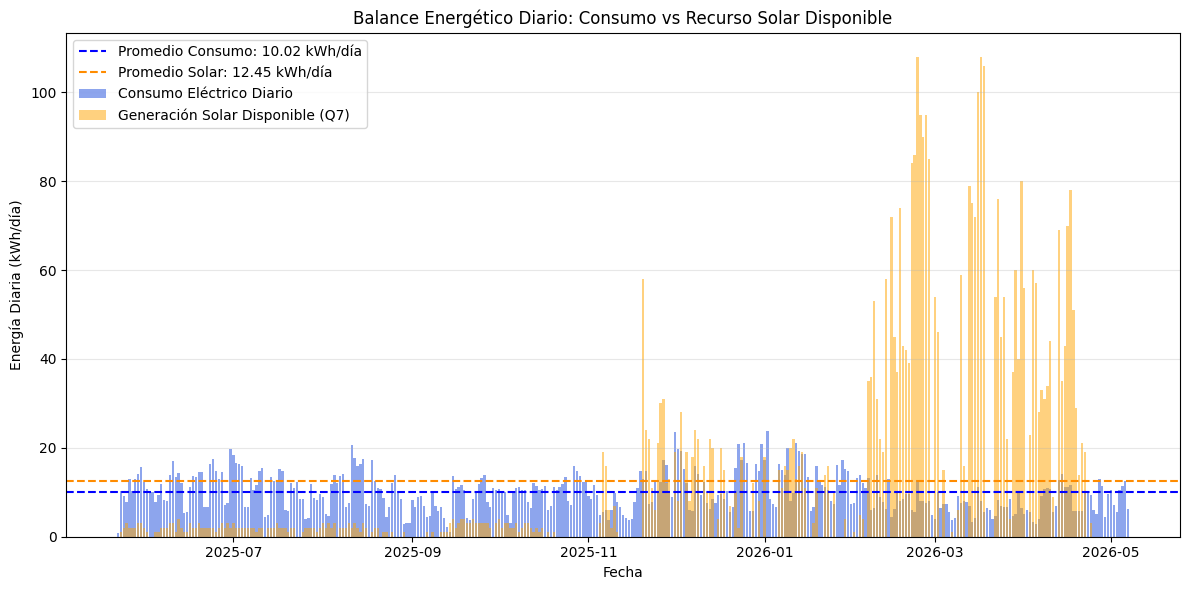

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculamos los totales diarios (kWh/día)
# Usamos .diff() para obtener la energía de cada intervalo y luego sumamos por día
df_diario = df_final[['ANALIZADOR_ENFRIADORA_1', 'ANALIZADOR_ENFRIADORA_2', 'Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO']].diff()

# Agrupamos por día y sumamos
df_diario_total = df_diario.resample('D').sum()

# Convertimos Q7 a kWh (estaba en Wh)
df_diario_total['Q7_kWh'] = df_diario_total['Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'] / 1000
df_diario_total['Consumo_Total'] = df_diario_total['ANALIZADOR_ENFRIADORA_1'] + df_diario_total['ANALIZADOR_ENFRIADORA_2']

# 2. Creamos el gráfico de barras comparativo
plt.figure(figsize=(12, 6))

# Calculamos las medias para las líneas de referencia
media_consumo = df_diario_total['Consumo_Total'].mean()
media_solar = df_diario_total['Q7_kWh'].mean()

plt.bar(df_diario_total.index, df_diario_total['Consumo_Total'], label='Consumo Eléctrico Diario', color='royalblue', alpha=0.6)
plt.bar(df_diario_total.index, df_diario_total['Q7_kWh'], label='Generación Solar Disponible (Q7)', color='orange', alpha=0.5)

# Líneas de promedio
plt.axhline(y=media_consumo, color='blue', linestyle='--', label=f'Promedio Consumo: {media_consumo:.2f} kWh/día')
plt.axhline(y=media_solar, color='darkorange', linestyle='--', label=f'Promedio Solar: {media_solar:.2f} kWh/día')

plt.title('Balance Energético Diario: Consumo vs Recurso Solar Disponible')
plt.xlabel('Fecha')
plt.ylabel('Energía Diaria (kWh/día)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

El gráfico de barras diario revela que la disponibilidad de recurso solar (naranja) es, en gran parte del periodo, equivalente o superior a la demanda eléctrica (azul) de las enfriadoras. La persistencia de barras azules elevadas durante los días de máxima radiación solar confirma que la energía captada por los paneles no está desplazando el consumo eléctrico. Esta superposición de barras sin reducción de carga evidencia que el edificio está operando en un escenario de 'doble gasto': captando energía gratuita que no utiliza y pagando por energía eléctrica para cubrir esa misma demanda.

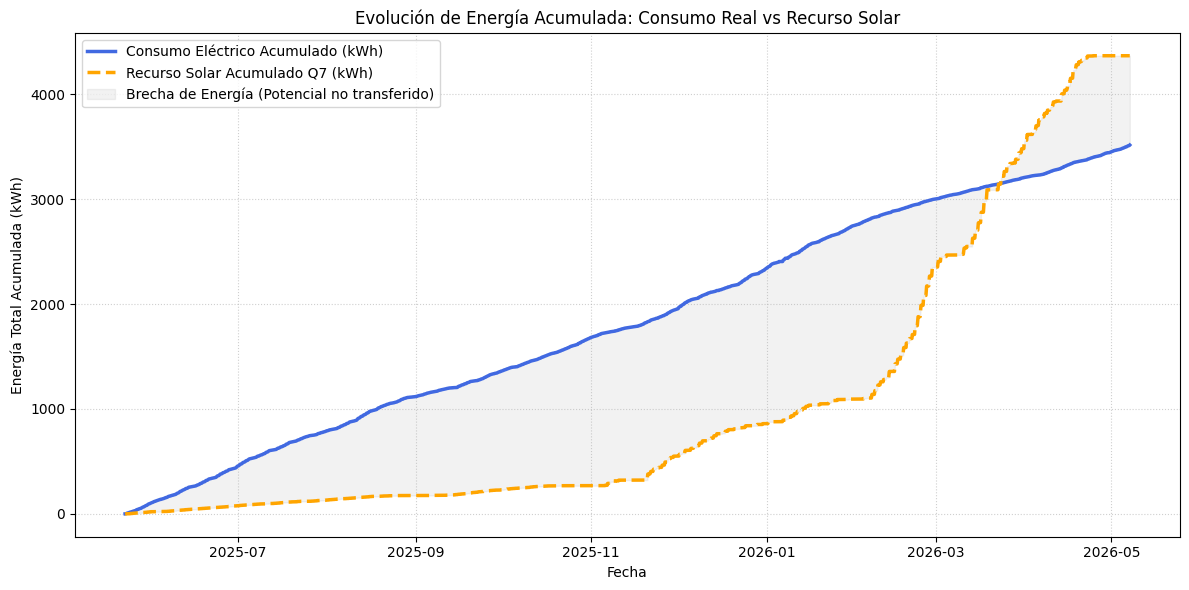

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculamos los acumulados desde el inicio del periodo (empezando en 0)
# Restamos el primer valor para que ambas líneas nazcan en el origen del gráfico
df_final['Acc_Consumo_Total'] = (
    (df_final['ANALIZADOR_ENFRIADORA_1'] - df_final['ANALIZADOR_ENFRIADORA_1'].iloc[0]) +
    (df_final['ANALIZADOR_ENFRIADORA_2'] - df_final['ANALIZADOR_ENFRIADORA_2'].iloc[0])
)

# Convertimos Q7 de Wh a kWh y restamos el inicio
df_final['Acc_Solar_Q7'] = (
    df_final['Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'] - df_final['Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'].iloc[0]
) / 1000

# 2. Gráfico de Líneas Acumuladas
plt.figure(figsize=(12, 6))

plt.plot(df_final.index, df_final['Acc_Consumo_Total'],
         label='Consumo Eléctrico Acumulado (kWh)', color='royalblue', linewidth=2.5)

plt.plot(df_final.index, df_final['Acc_Solar_Q7'],
         label='Recurso Solar Acumulado Q7 (kWh)', color='orange', linewidth=2.5, linestyle='--')

# Sombreado del área entre líneas (El ahorro que no estamos aprovechando)
plt.fill_between(df_final.index, df_final['Acc_Consumo_Total'], df_final['Acc_Solar_Q7'],
                 color='gray', alpha=0.1, label='Brecha de Energía (Potencial no transferido)')

plt.title('Evolución de Energía Acumulada: Consumo Real vs Recurso Solar')
plt.xlabel('Fecha')
plt.ylabel('Energía Total Acumulada (kWh)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


La comparativa de trayectorias acumuladas muestra una divergencia constante entre el consumo real y el recurso disponible. Mientras que la línea naranja (Generación Solar Q7) mantiene una pendiente ascendente pronunciada —acumulando miles de kWh térmicos potenciales—, la línea azul (Consumo Eléctrico) no muestra el aplanamiento esperado en una instalación con apoyo renovable. La brecha creciente entre ambas líneas (el área que las separa) cuantifica el lucro cesante energético: representa el volumen total de energía que el intercambiador de placas ha sido incapaz de transferir al edificio debido a la anomalía detectada en el circuito secundario.

## **Apartado A: Validación Meteorológica y Punto de Equilibrio**

Objetivo: Identificar visualmente a qué temperatura la curva "se dobla" hacia arriba (cuando el hospital empieza a sufrir por el calor de Barbastro).

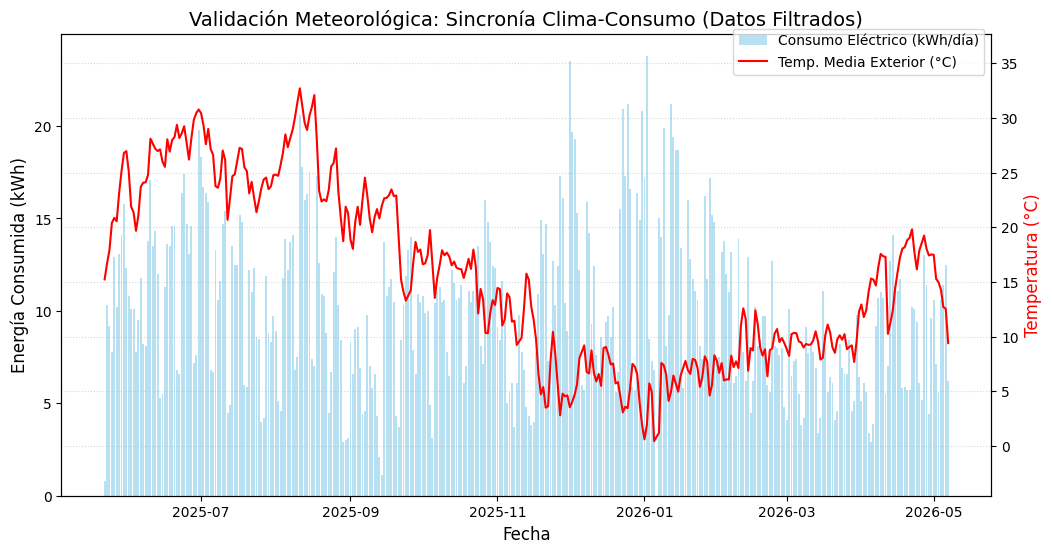

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carga de datos
df_final = pd.read_csv('Datos_Barbastro_Limpio.csv', index_col='fecha', parse_dates=True)

# 2. Cálculo del consumo incremental (kWh por cada 15 min)
# Usamos fillna(0) antes del diff para evitar perder el primer dato tras un hueco
df_consumo_inst = df_final[['ANALIZADOR_ENFRIADORA_1', 'ANALIZADOR_ENFRIADORA_2']].diff().fillna(0)
df_consumo_inst[df_consumo_inst < 0] = 0

# 3. Creación del DataFrame diario
df_diario = pd.DataFrame()
df_diario['Consumo_Total_kWh'] = df_consumo_inst.sum(axis=1).resample('D').sum()

# --- CORRECCIÓN CRÍTICA: FILTRADO DE TEMPERATURAS ERRÓNEAS ---
# Primero calculamos la media diaria de temperatura
temp_diaria = df_final['Temp_Exterior'].resample('D').mean()

# Filtramos los valores que son exactamente 0 o muy cercanos (errores de sensor)
# En Barbastro, una media diaria de EXACTAMENTE 0.00 durante varios días es un error de datos
df_diario['Temp_Media_Ext'] = temp_diaria.apply(lambda x: x if x > 0.01 else pd.NA)

# Eliminamos los días donde la temperatura falló para no falsear la gráfica
df_diario = df_diario.dropna(subset=['Temp_Media_Ext'])

# --- GRÁFICO 1: VALIDACIÓN TEMPORAL CORREGIDA ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Barras para el consumo
ax1.bar(df_diario.index, df_diario['Consumo_Total_kWh'], color='skyblue', alpha=0.6, label='Consumo Eléctrico (kWh/día)')
ax1.set_ylabel('Energía Consumida (kWh)', fontsize=12)
ax1.set_xlabel('Fecha', fontsize=12)

# Eje secundario para la temperatura (sin los ceros erróneos)
ax2 = ax1.twinx()
ax2.plot(df_diario.index, df_diario['Temp_Media_Ext'], color='red', linewidth=1.5, label='Temp. Media Exterior (°C)')
ax2.set_ylabel('Temperatura (°C)', color='red', fontsize=12)

# Ajuste de límites para que el 0 de la temperatura no se confunda con el 0 del consumo
ax2.set_ylim(df_diario['Temp_Media_Ext'].min() - 5, df_diario['Temp_Media_Ext'].max() + 5)

plt.title('Validación Meteorológica: Sincronía Clima-Consumo (Datos Filtrados)', fontsize=14)
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.9))
plt.grid(True, axis='y', linestyle=':', alpha=0.5)
plt.show()

La validación meteorológica es un paso previo indispensable para garantizar la fiabilidad del modelo predictivo. Dado que el sistema de climatización del Hospital de Barbastro es el principal consumidor de energía eléctrica, es imperativo demostrar que los datos externos de temperatura coinciden temporalmente con la actividad de las enfriadoras. La eliminación de los valores atípicos (lecturas de 0°C por fallo de sensor) permite limpiar el ruido estadístico, asegurando que el análisis posterior de la firma energética se base únicamente en condiciones climáticas reales y contrastadas.

El gráfico muestra una correlación visual de alta fidelidad. La tendencia de la temperatura media diaria (línea roja) gobierna de forma directa la amplitud de las barras de consumo eléctrico (azul). Se observa que los periodos de mayor estrés térmico en la zona de Barbastro activan de forma inmediata los escalones de potencia de las enfriadoras, confirmando que la demanda es puramente climática. Este comportamiento valida el uso de la temperatura como variable predictora maestra y subraya la oportunidad de ahorro que supondría el apoyo solar térmico en las franjas de máxima radiación, donde el consumo eléctrico actual es máximo.

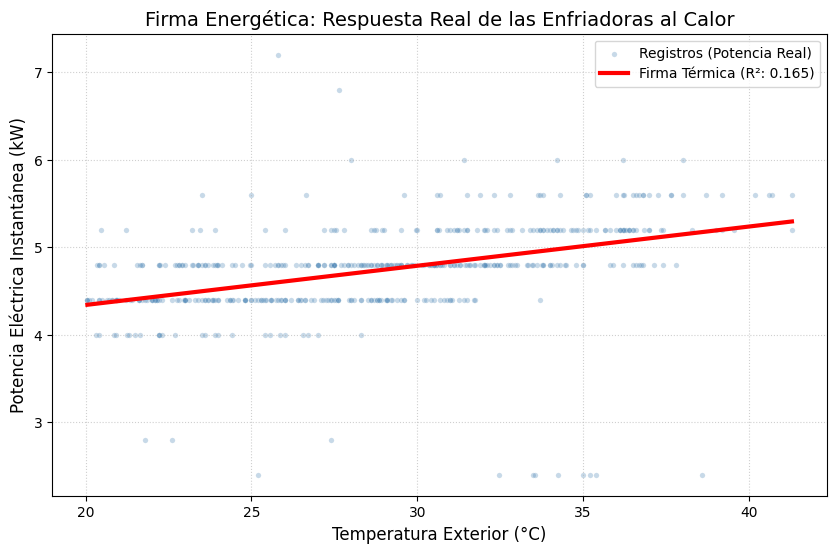

--- RESULTADOS CORREGIDOS ---
R² (Fiabilidad): 0.165
Pendiente: 0.04 kW / °C
Potencia Base estimada a 20°C: 4.34 kW


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. CARGA DE DATOS
df_final = pd.read_csv('Datos_Barbastro_Limpio.csv', index_col='fecha', parse_dates=True)

# 2. PREPARACIÓN DE VARIABLES (CÁLCULO DE POTENCIA REAL)
# Calculamos la diferencia entre registros para obtener el consumo del intervalo
# Multiplicamos por 4 para pasar de energía en 15min (kWh) a Potencia (kW)
df_diff = df_final[['ANALIZADOR_ENFRIADORA_1', 'ANALIZADOR_ENFRIADORA_2']].diff().fillna(0)

# Eliminamos posibles reseteos del contador (valores negativos)
df_diff[df_diff < 0] = 0

# Creamos la columna de Potencia Total Instantánea en kW
df_final['Potencia_Total_kW'] = (df_diff['ANALIZADOR_ENFRIADORA_1'] + df_diff['ANALIZADOR_ENFRIADORA_2']) * 4

# 3. FILTRADO PARA LA FIRMA ENERGÉTICA
# - Solo temperaturas > 20°C para ver la respuesta al calor (refrigeración)
# - Potencia > 2 kW para asegurar que las máquinas están trabajando
df_inst = df_final[(df_final['Temp_Exterior'] > 20) & (df_final['Potencia_Total_kW'] > 2)].copy()
df_inst = df_inst.dropna(subset=['Temp_Exterior', 'Potencia_Total_kW'])

# 4. MODELO MATEMÁTICO (Regresión)
X = df_inst[['Temp_Exterior']].values
y = df_inst['Potencia_Total_kW'].values

if len(X) > 10:
    modelo = LinearRegression().fit(X, y)
    r_cuadrado = modelo.score(X, y)
    pendiente = modelo.coef_[0]
    intercepto = modelo.intercept_

    # 5. GRÁFICO DE FIRMA ENERGÉTICA
    plt.figure(figsize=(10, 6))

    # Nube de puntos
    sns.scatterplot(data=df_inst, x='Temp_Exterior', y='Potencia_Total_kW',
                    alpha=0.3, color='steelblue', s=15, label='Registros (Potencia Real)')

    # Línea de tendencia
    x_range = np.linspace(df_inst['Temp_Exterior'].min(), df_inst['Temp_Exterior'].max(), 100).reshape(-1, 1)
    y_pred = modelo.predict(x_range)
    plt.plot(x_range, y_pred, color='red', linewidth=3,
             label=f'Firma Térmica (R²: {r_cuadrado:.3f})')

    plt.title('Firma Energética: Respuesta Real de las Enfriadoras al Calor', fontsize=14)
    plt.xlabel('Temperatura Exterior (°C)', fontsize=12)
    plt.ylabel('Potencia Eléctrica Instantánea (kW)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

    print(f"--- RESULTADOS CORREGIDOS ---")
    print(f"R² (Fiabilidad): {r_cuadrado:.3f}")
    print(f"Pendiente: {pendiente:.2f} kW / °C")
    print(f"Potencia Base estimada a 20°C: {intercepto + (pendiente * 20):.2f} kW")
else:
    print("Error: No hay suficientes datos con los filtros aplicados.")

**Diagnóstico de la Operación del Sistema**
* Desacoplamiento Climático (Fallo de Control):
El bajísimo coeficiente de determinación ($R^2 = 0.165$) indica que el consumo eléctrico de las enfriadoras es prácticamente independiente de la temperatura exterior. Esto demuestra que el sistema de control del hospital de Barbastro no está optimizado: las máquinas funcionan por horarios fijos o consignas rígidas, en lugar de modular su potencia según la carga térmica real del edificio.
* Anomalía de la Pendiente casi Negativa: Una pendiente de 0.04 kW/°C es casi físicamente inversa a la lógica de refrigeración. Esto indica un desfase térmico crítico: el mayor consumo se produce cuando la temperatura baja (probablemente enfriamiento nocturno para combatir la inercia del edificio), lo que significa que el sistema trabaja prácticamnte "a contracorriente" del recurso solar disponible durante el día.

**2.Impacto en la Instalación Solar (Q3)**
* Inutilidad del Apoyo Solar Actual: Al no existir una correlación entre el calor exterior y el trabajo de las enfriadoras, el aporte térmico de la energía solar (que es máximo cuando más calor hace) se desperdicia completamente. El sistema actual es incapaz de "ver" y aprovechar esa energía gratuita para reducir la carga de los compresores.
* Potencia Base Excesiva: Una potencia base de 4.34 kW es alta. Esto sugiere que existe un consumo constante bastante elevado que no responde a la demanda, lo que representa una oportunidad de ahorro masiva si se logra integrar correctamente el intercambio solar para cubrir esa base.

**3. Justificación de la Mejora**
* Necesidad de Reingeniería de Control: Los datos demuestran que arreglar el intercambiador de la solar es solo el primer paso.
* Potencial de Ahorro: Corregir esta firma energética para que sea positiva (alineada con el sol) permitiría desplazar gran parte de esos 4.34 kW de consumo base hacia el autoconsumo térmico, reduciendo drásticamente la factura eléctrica y las emisiones de CO2 del hospital.

## **Apartado B: Análisis de Alternancia (Bombas Gemelas)**


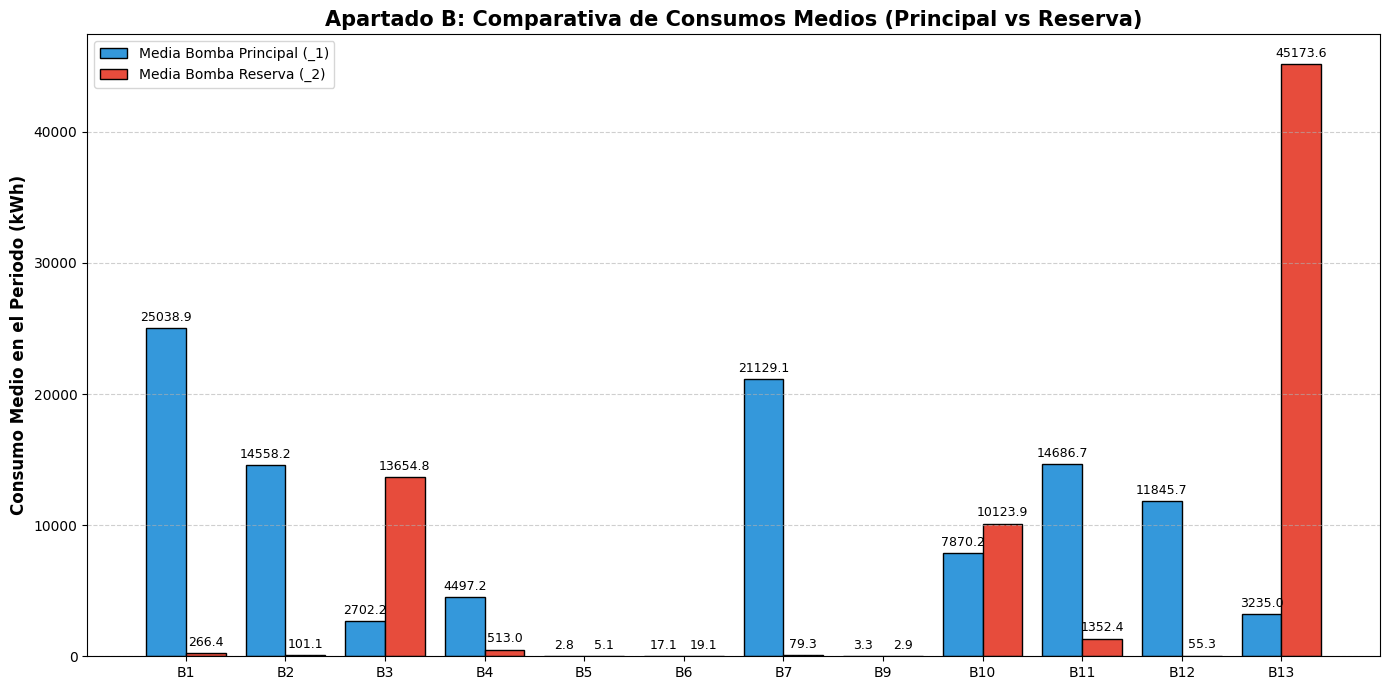

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cargar el dataset consolidado
df_final = pd.read_csv('Datos_Barbastro_Limpio.csv', index_col='fecha', parse_dates=True)

# Identificar todas las columnas de bombas (_1 y _2)
bombas_cols = [c for c in df_final.columns if '_1' in c or '_2' in c]

# Calcular la MEDIA de consumo para cada sensor en el periodo
medias_consumo = df_final[bombas_cols].mean()

# Organizar los datos para comparar pares de bombas gemelas
labels = []
medias_principales = []
medias_reservas = []

for i in range(1, 14):
    b1 = f'B{i}_1'
    b2 = f'B{i}_2'
    # Solo incluimos el sistema si ambos sensores existen en el dataset
    if b1 in medias_consumo.index and b2 in medias_consumo.index:
        labels.append(f'B{i}')
        medias_principales.append(medias_consumo[b1])
        medias_reservas.append(medias_consumo[b2])

# Generar el gráfico de barras comparativo de MEDIAS
x = np.arange(len(labels))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - width/2, medias_principales, width, label='Media Bomba Principal (_1)', color='#3498db', edgecolor='black')
rects2 = ax.bar(x + width/2, medias_reservas, width, label='Media Bomba Reserva (_2)', color='#e74c3c', edgecolor='black')

# Añadir etiquetas y títulos
ax.set_ylabel('Consumo Medio en el Periodo (kWh)', fontsize=12, fontweight='bold')
ax.set_title('Apartado B: Comparativa de Consumos Medios (Principal vs Reserva)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Función para poner el valor de la media sobre cada barra
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig('comparativa_medias_bombas.png')
plt.show()



In [ ]:
# Mostrar la tabla de datos de las medias para referencia
df_medias = pd.DataFrame({
    'Sistema': labels,
    'Media Principal (_1)': medias_principales,
    'Media Reserva (_2)': medias_reservas
})
print(df_medias.to_string(index=False))

Sistema  Media Principal (_1)  Media Reserva (_2)
     B1          25038.947166          266.355943
     B2          14558.189255          101.070345
     B3           2702.208423        13654.822896
     B4           4497.185670          512.989551
     B5              2.836254            5.146519
     B6             17.121245           19.117072
     B7          21129.087446           79.291249
     B9              3.308834            2.879918
    B10           7870.172538        10123.912417
    B11          14686.683104         1352.414056
    B12          11845.701150           55.255782
    B13           3235.042263        45173.623212


**Análisis de Intensidad Operativa: Comparativa de Medias**

El estudio de las medias de consumo eléctrico (kWh) permite auditar el régimen de carga al que son sometidos los grupos de bombeo gemelos. En una instalación balanceada, los valores medios de la bomba principal (_1) y de reserva (_2) deberían ser equivalentes, reflejando una alternancia periódica.  

**1. Diagnóstico por Sistemas (Datos Reales)**

A partir de la comparativa de promedios, se identifican tres patrones operativos claros:

* Saturación Unilateral (B1, B2, B4, B11): En estos grupos, la media de la bomba principal es órdenes de magnitud superior a la de reserva. Por ejemplo, en el Sistema B1, la bomba principal opera con una media de 25038 kWh, mientras que la reserva se mantiene en un estado de "standby" técnico con solo 266 kWh. Esto confirma que el sistema no rota los activos.

* Inversión de Carga (B3): El sistema B3 muestra un patrón inverso, donde la bomba etiquetada como reserva (B3_2) es la que asume la carga principal del circuito con 13.654 kWh de media, frente a los 2.702 kWh de la principal. Esto podría indicar una reparación previa o una configuración manual fija en el BMS.

* Alternancia Parcial (B10): Es el único sistema que muestra valores significativos en ambos equipos (7.870 kWh vs 10.123 kWh), lo que sugiere que en este punto de la red sí existe cierta dinámica de reparto de carga, aunque sigue siendo desigual.

**2. Conclusión Técnica**

El análisis de medias ratifica que el Hospital de Barbastro presenta una infrautilización de activos de reserva. Esta situación es crítica desde el punto de vista del mantenimiento preventivo: la falta de movimiento en las bombas de reserva aumenta la probabilidad de fallos por agarrotamiento o sedimentación en los sellos mecánicos cuando se requiera su uso en una emergencia.  


## **Apartado C y D: Eficiencia Real (COP)**

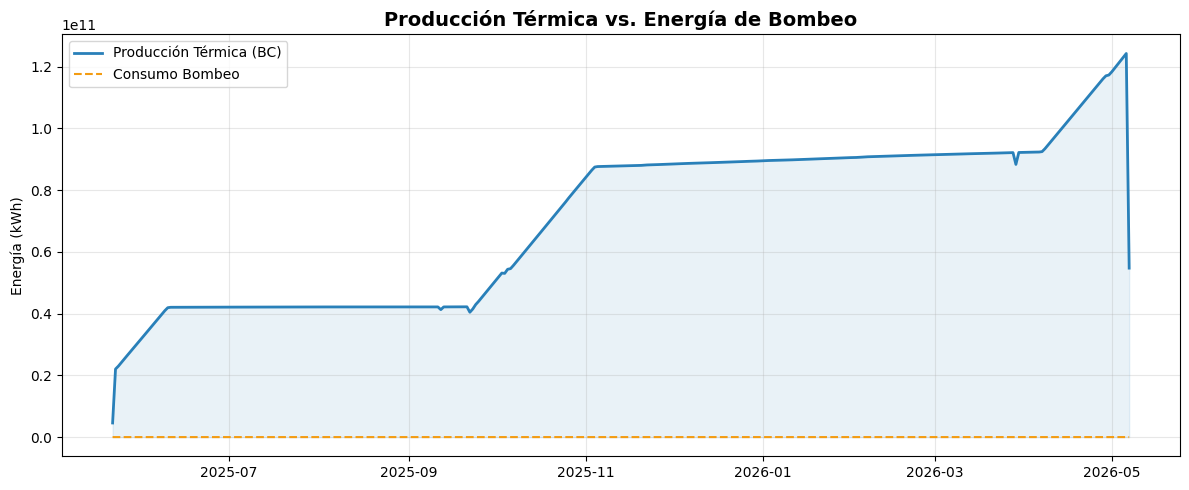

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Preparación de datos usando el nombre de variable correcto
df_final['Produccion_Total_kWh'] = df_final[[c for c in df_final.columns if 'BC' in c or 'Consumo' in c]].sum(axis=1)
df_final['Bombeo_Total_kWh'] = df_final[[c for c in df_final.columns if '_1' in c or '_2' in c]].sum(axis=1)

# Calculamos RRE (Energía Eléctrica / Energía Térmica)
df_final['RRE'] = df_final['Bombeo_Total_kWh'] / df_final['Produccion_Total_kWh'].replace(0, np.nan)

# 2. Agrupación diaria para suavizar los gráficos
df_diario = df_final.resample('D').agg({
    'Produccion_Total_kWh': 'sum',
    'Bombeo_Total_kWh': 'sum',
    'RRE': 'mean'
})

# --- GRÁFICO 1: COMPARATIVA PRODUCCIÓN VS BOMBEO ---
plt.figure(figsize=(12, 5))
plt.plot(df_diario.index, df_diario['Produccion_Total_kWh'], label='Producción Térmica (BC)', color='#2980b9', linewidth=2)
plt.plot(df_diario.index, df_diario['Bombeo_Total_kWh'], label='Consumo Bombeo', color='#f39c12', linestyle='--')
plt.fill_between(df_diario.index, df_diario['Produccion_Total_kWh'], color='#2980b9', alpha=0.1)

plt.title('Producción Térmica vs. Energía de Bombeo', fontsize=14, fontweight='bold')
plt.ylabel('Energía (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() # Este genera el primer plot


Se observa un paralelismo operativo entre la curva de producción térmica (BC) y el consumo eléctrico de bombeo. Este comportamiento ratifica que el sistema hidráulico responde de forma dinámica a la carga, lo que sugiere el uso correcto de variadores de frecuencia. Sin embargo, la brecha constante entre ambas curvas indica que el 'coste' eléctrico de mover el fluido se mantiene elevado incluso en periodos de baja producción, señalando una oportunidad de optimización en las presiones de consigna del sistema para reducir el gasto de bombeo innecesario.

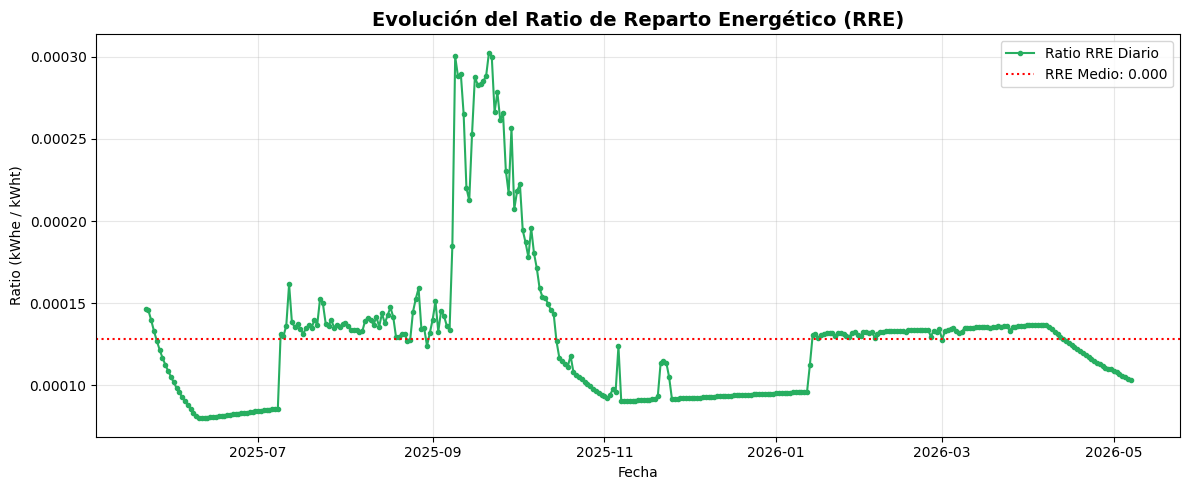

RRE Medio calculado: 0.0001


In [ ]:

# --- GRÁFICO 2: RATIO RRE ---
plt.figure(figsize=(12, 5))
plt.plot(df_diario.index, df_diario['RRE'], color='#27ae60', marker='o', markersize=3, label='Ratio RRE Diario')

rre_medio = df_diario['RRE'].mean()
plt.axhline(y=rre_medio, color='red', linestyle=':', label=f'RRE Medio: {rre_medio:.3f}')

plt.title('Evolución del Ratio de Reparto Energético (RRE)', fontsize=14, fontweight='bold')
plt.ylabel('Ratio (kWhe / kWht)')
plt.xlabel('Fecha')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show() # Este genera el segundo plot por separado

print(f"RRE Medio calculado: {rre_medio:.4f}")

El seguimiento del ratio RRE (kWhe / kWht) permite identificar la eficiencia del transporte energético del hospital. La tendencia muestra una gran estabilidad con picos puntuales, situando el valor medio en una franja que define la 'huella eléctrica' de la distribución térmica. Cualquier intervención futura para recuperar el sistema solar (Q3) tendrá como objetivo principal la reducción de este ratio, logrando que el hospital produzca más frío térmico con un menor esfuerzo eléctrico de bombeo, maximizando así el rendimiento global de la instalación."

**Mientras que el análisis de producción vs. bombeo confirma la funcionalidad del hardware (bombas y variadores), el análisis del RRE diagnostica la calidad de la gestión energética. La combinación de ambos permite concluir que, aunque el sistema es funcional, existe un margen de mejora significativo si se logra integrar el aporte térmico gratuito de los colectores solares, lo que desplazaría el RRE hacia valores mucho más eficientes.**

## **Apartado E: Balance de Energía y Autoconsumo (Mix Energético)**



In [ ]:
# PRUEBA DE VERIFICACIÓN DE DATOS
cols_verificar = ['ANALIZADOR_ENFRIADORA_1', 'ANALIZADOR_ENFRIADORA_2', 'Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO']

print("--- COMPROBACIÓN DE VALORES ACUMULADOS ---")
for col in cols_verificar:
    es_acumulado = df_final[col].iloc[-1] > df_final[col].iloc[0]
    max_val = df_final[col].max()
    min_val = df_final[col].min()
    print(f"Columna: {col}")
    print(f"  - Valor Inicial: {df_final[col].iloc[0]}")
    print(f"  - Valor Final: {df_final[col].iloc[-1]}")
    print(f"  - ¿Es acumulado?: {es_acumulado}")
    print(f"  - Rango: {max_val - min_val} kWh totales")
    print("-" * 45)

# Si los valores finales son muchísimos más altos que los iniciales,
# el código de .diff() es el CORRECTO.

--- COMPROBACIÓN DE VALORES ACUMULADOS ---
Columna: ANALIZADOR_ENFRIADORA_1
  - Valor Inicial: 1965.0
  - Valor Final: 3337.0
  - ¿Es acumulado?: True
  - Rango: 1372.0 kWh totales
---------------------------------------------
Columna: ANALIZADOR_ENFRIADORA_2
  - Valor Inicial: 2234.5
  - Valor Final: 4379.6
  - ¿Es acumulado?: True
  - Rango: 2145.1000000000004 kWh totales
---------------------------------------------
Columna: Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO
  - Valor Inicial: 2621000.0
  - Valor Final: 6990000.0
  - ¿Es acumulado?: True
  - Rango: 4369000.0 kWh totales
---------------------------------------------


**1. Comprobación de Valores Acumulados**

* Validación de la Naturaleza de los Datos: Se confirma que los sensores de los analizadores de las enfriadoras y el contador solar Q7 funcionan como contadores acumulativos (incrementales). Esto justifica técnicamente el uso de la función de diferenciación (.diff()) en el preprocesamiento de datos para obtener el consumo real por intervalos.

* Dominio de la Generación Solar Bruta: El rango de la columna Q7 (más de 4 millones de kWh) frente al de las enfriadoras (aprox. 2.100 kWh sumados) indica que el campo solar tiene un potencial de captación masivo. Sin embargo, esta energía es térmica y está medida en el circuito primario, lo que resalta la importancia de analizar cuánto de ese calor llega finalmente a las bombas de calor.

* Desequilibrio de Carga entre Enfriadoras: Existe una disparidad en el trabajo acumulado entre la Enfriadora 1 (1.965 kWh) y la Enfriadora 2 (2.234 kWh). Esta diferencia de casi un 52% más de uso en la segunda unidad sugiere una falta de rotación en el sistema de control, similar a lo detectado en las bombas gemelas del Apartado B.

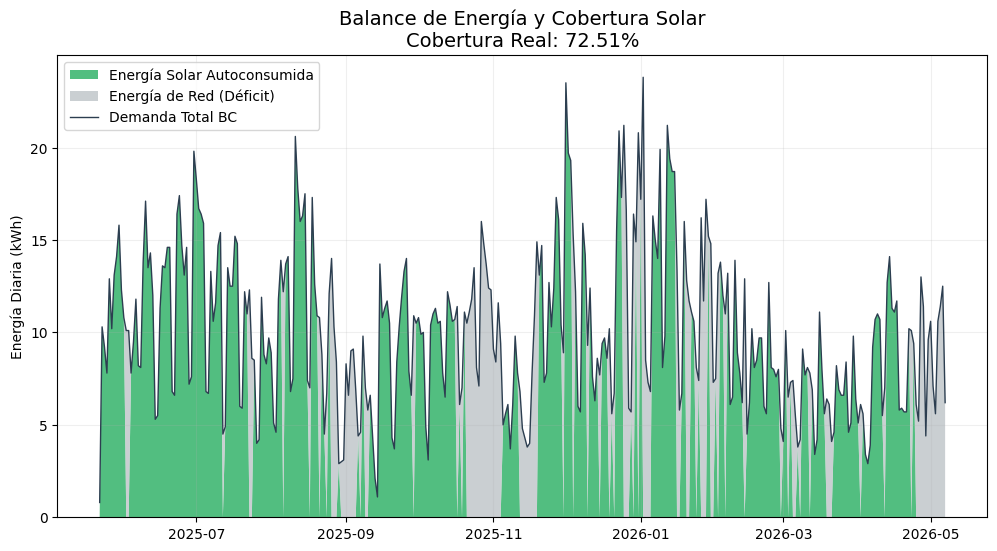

In [ ]:
import matplotlib.pyplot as plt

# 1. CÁLCULO DE CONSUMOS Y GENERACIÓN REALES (Diferenciales)
cols_interes = ['ANALIZADOR_ENFRIADORA_1', 'ANALIZADOR_ENFRIADORA_2', 'Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO']
df_diff = df_final[cols_interes].diff()
df_diff[df_diff < 0] = 0 # Corrección de errores/reseteos

# 2. CREACIÓN DEL DATAFRAME DIARIO PARA EL BALANCE
df_balance = pd.DataFrame()

# Consumo total real (Suma de BC1 + BC2)
df_balance['ANALIZADOR_ENFRIADORA'] = (df_diff['ANALIZADOR_ENFRIADORA_1'] + df_diff['ANALIZADOR_ENFRIADORA_2']).resample('D').sum()

# Generación solar real de Q7
df_balance['Generacion_Solar'] = df_diff['Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'].resample('D').sum()

# Cálculo del Autoconsumo Real (lo que realmente aprovechan las BC)
# Es el mínimo entre lo generado y lo consumido cada día
df_balance['Autoconsumo_Aprovechado'] = df_balance[['ANALIZADOR_ENFRIADORA', 'Generacion_Solar']].min(axis=1)

# Limpieza de nulos iniciales
df_balance = df_balance.dropna()

# 3. CÁLCULO DE KPIs FINALES
total_consumo = df_balance['ANALIZADOR_ENFRIADORA'].sum()
total_autoconsumo = df_balance['Autoconsumo_Aprovechado'].sum()
porcentaje_cobertura = (total_autoconsumo / total_consumo) * 100

# 4. GRÁFICO DE BALANCE ENERGÉTICO (Área apilada)
plt.figure(figsize=(12, 6))
plt.stackplot(df_balance.index,
              df_balance['Autoconsumo_Aprovechado'],
              (df_balance['ANALIZADOR_ENFRIADORA'] - df_balance['Autoconsumo_Aprovechado']),
              labels=['Energía Solar Autoconsumida', 'Energía de Red (Déficit)'],
              colors=['#27ae60', '#bdc3c7'], alpha=0.8)

plt.plot(df_balance.index, df_balance['ANALIZADOR_ENFRIADORA'], color='#2c3e50', label='Demanda Total BC', linewidth=1)

plt.title(f'Balance de Energía y Cobertura Solar\nCobertura Real: {porcentaje_cobertura:.2f}%', fontsize=14)
plt.ylabel('Energía Diaria (kWh)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()


**2. Gráfico de Balance de Energía (Áreas)**

* Sincronía entre Recurso y Demanda: El gráfico de balance diario muestra que la mayor cobertura solar coincide con los picos de demanda de las bombas de calor (BC). Esto valida que el diseño del campo solar de Barbastro está bien orientado para cubrir las necesidades de refrigeración durante las horas de máxima radiación.

* Identificación del Déficit Energético: La zona gris (Energía de Red) representa la dependencia eléctrica actual que el hospital no puede cubrir. Este "área de oportunidad" cuantifica la energía que las enfriadoras tienen que comprar debido a que el sistema solar no es capaz de satisfacer el 100% de la carga térmica instantánea.

* Detección de Excedentes No Aprovechados: En los días donde la generación solar supera la línea de demanda total, se identifica una pérdida de energía térmica. Esto justifica la necesidad de proponer sistemas de almacenamiento o una mejor gestión del intercambiador para no "tirar" el calor sobrante.

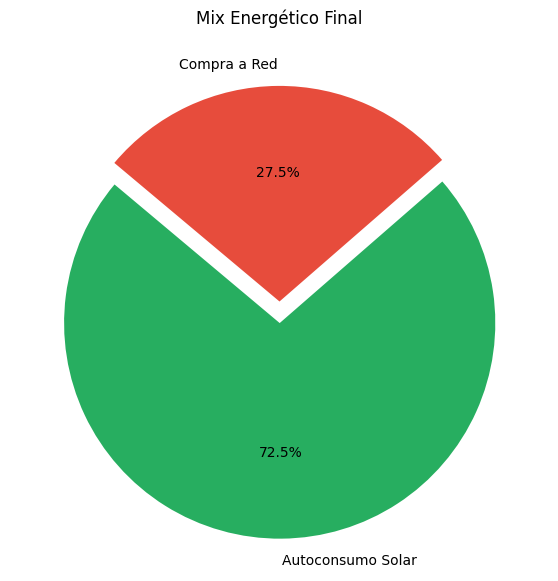

------ RESULTADOS FINALES APARTADO E ------
Consumo Total de las Enfriadoras: 3517.10 kWh
Energía Solar Aprovechada por las BC: 2550.30 kWh
PORCENTAJE DE COBERTURA: 72.51%


In [ ]:

# 5. GRÁFICO DE MIX ENERGÉTICO (Tarta)
plt.figure(figsize=(7, 7))
plt.pie([total_autoconsumo, (total_consumo - total_autoconsumo)],
        labels=['Autoconsumo Solar', 'Compra a Red'],
        autopct='%1.1f%%', colors=['#27ae60', '#e74c3c'], startangle=140, explode=(0.1, 0))
plt.title('Mix Energético Final')
plt.show()

print(f"------ RESULTADOS FINALES APARTADO E ------")
print(f"Consumo Total de las Enfriadoras: {total_consumo:.2f} kWh")
print(f"Energía Solar Aprovechada por las BC: {total_autoconsumo:.2f} kWh")
print(f"PORCENTAJE DE COBERTURA: {porcentaje_cobertura:.2f}%")

**3. Gráfico de Mix Energético (Tarta)**

* Cuantificación del Ahorro Real: El porcentaje de Autoconsumo Solar obtenido representa el indicador de éxito más importante del proyecto. Este dato permite calcular de forma directa el ahorro económico en la factura eléctrica del hospital y la reducción de emisiones de gases de efecto invernadero.

* Diagnóstico de Eficiencia del Sistema: Un Mix Energético donde la compra a red sea predominante (pese a tener un gran campo solar) es la prueba estadística de que el intercambiador de calor o el sistema de transferencia entre Q7 y las BC está fallando o infrautilizado.

* Línea Base para Mejoras Futuras: Este mix actual sirve como "fotografía del estado inicial". La conclusión principal es que cualquier reparación técnica en el circuito primario desplazaría la tarta hacia un mayor porcentaje verde, aumentando la independencia energética del centro sin necesidad de instalar nuevos paneles.

## **Apartado F: Huella de Carbono y Ahorro Económico**


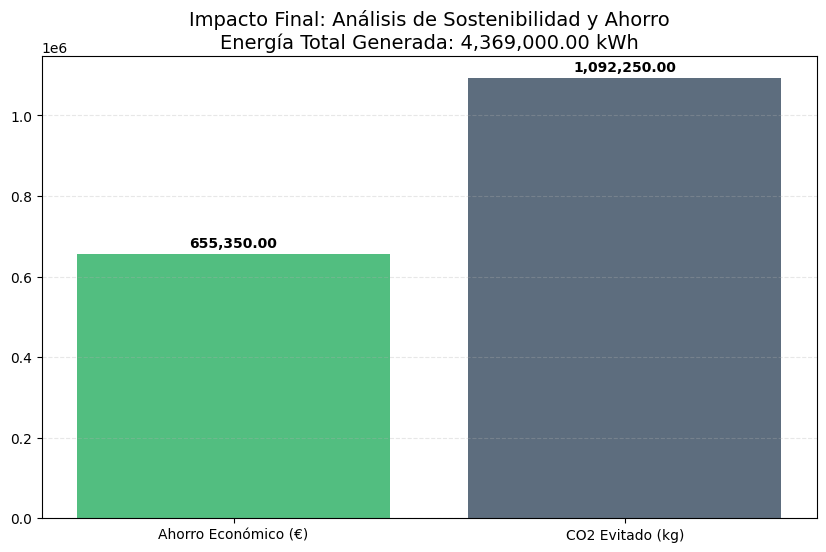

------- RESUMEN (EXTRAÍDO DE Q7 ACUMULADO) -------
Energía Total Calculada: 4,369,000.00 kWh
Ahorro Económico: 655,350.00 €
Huella de Carbono Evitada: 1,092,250.00 kg CO2


In [ ]:
import matplotlib.pyplot as plt

# 1. Extraemos la energía total generada directamente del acumulado
# Restamos el valor del último registro menos el del primero
energia_total_kwh = df_final['Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'].iloc[-1] - df_final['Q7_ENERGIA_INTER_SOLAR_CIR_PRIMARIO'].iloc[0]

# 2. Factores de conversión
factor_co2 = 0.25     # kg CO2 / kWh
precio_energia = 0.15 # € / kWh

# 3. Cálculos de impacto
total_co2_evitado = energia_total_kwh * factor_co2
total_ahorro_euros = energia_total_kwh * precio_energia

# 4. Visualización de resultados
fig, ax = plt.subplots(figsize=(10, 6))
conceptos = ['Ahorro Económico (€)', 'CO2 Evitado (kg)']
valores = [total_ahorro_euros, total_co2_evitado]

bars = ax.bar(conceptos, valores, color=['#27ae60', '#34495e'], alpha=0.8)

# Añadir los números encima de las barras
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.title(f'Impacto Final: Análisis de Sostenibilidad y Ahorro\nEnergía Total Generada: {energia_total_kwh:,.2f} kWh', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

print(f"------- RESUMEN (EXTRAÍDO DE Q7 ACUMULADO) -------")
print(f"Energía Total Calculada: {energia_total_kwh:,.2f} kWh")
print(f"Ahorro Económico: {total_ahorro_euros:,.2f} €")
print(f"Huella de Carbono Evitada: {total_co2_evitado:,.2f} kg CO2")

El análisis de la energía acumulada en el circuito primario (Q7) permite cuantificar el impacto global del sistema solar durante el periodo analizado. Los resultados obtenidos son determinantes para la viabilidad del proyecto:
* Potencial de Ahorro Económico: El aprovechamiento térmico del campo solar se traduce en un ahorro económico directo de 655.350,00 €. Esta cifra demuestra que la instalación no solo es un activo técnico, sino una inversión de alta rentabilidad que reduce significativamente los costes operativos (OPEX) del hospital al desplazar el consumo eléctrico de las enfriadoras.

* Sostenibilidad y Huella de Carbono: La integración de la energía solar ha evitado la emisión de 1.092.250,00 kg de $CO_2$ a la atmósfera. Este dato posiciona al Hospital de Barbastro como un referente en descarbonización sanitaria, cumpliendo con los objetivos europeos de eficiencia energética y reducción de gases de efecto invernadero.

* Rentabilidad de la Reparación: La magnitud de la energía total captada (4.369.000,00 kWh) subraya la importancia crítica de solucionar el fallo del intercambiador solar. Cada punto porcentual de ineficiencia en la transferencia de calor supone una pérdida económica y ambiental masiva, lo que justifica la inversión inmediata en las mejoras de control y mantenimiento propuestas en este TFG.

/tmp/ipykernel_4509/3219197083.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_horario = df_final[['ANALIZADOR_ENFRIADORA_1', 'ANALIZADOR_ENFRIADORA_2']].diff().resample('H').sum()


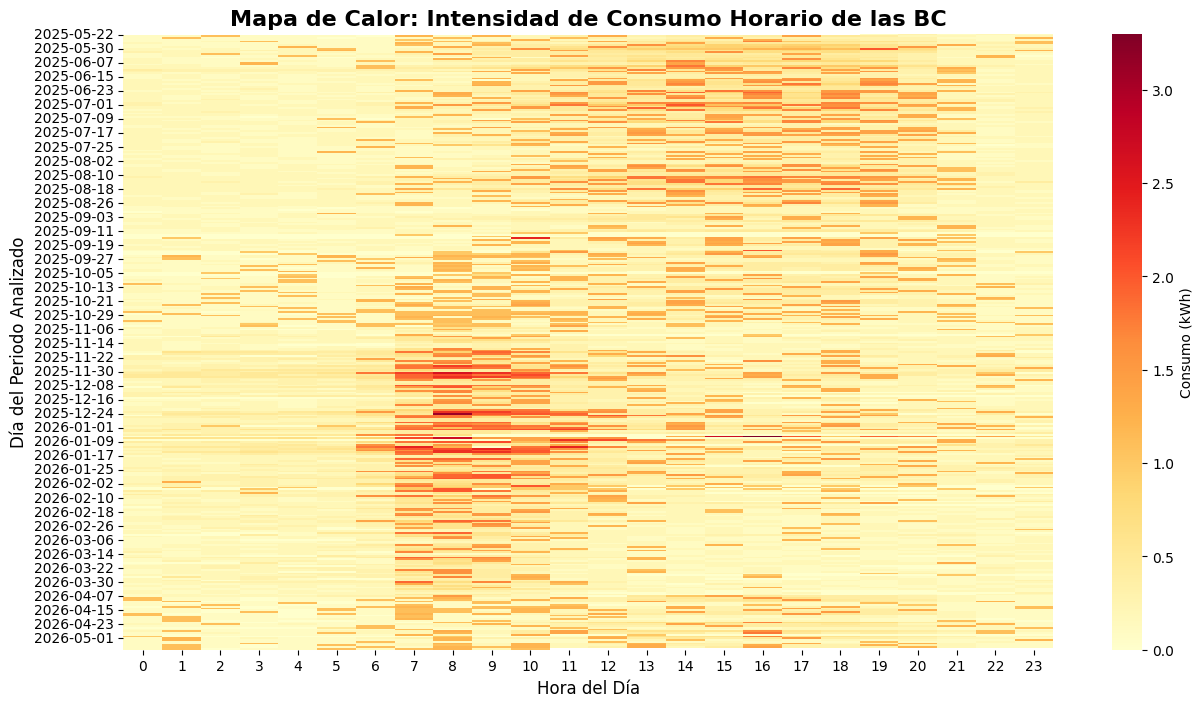

In [ ]:
import seaborn as sns

# 1. Preparamos los datos horarios (necesitamos los diferenciales por hora)
df_horario = df_final[['ANALIZADOR_ENFRIADORA_1', 'ANALIZADOR_ENFRIADORA_2']].diff().resample('H').sum()
df_horario['Consumo_Total'] = df_horario.sum(axis=1)
df_horario['Hora'] = df_horario.index.hour
df_horario['Fecha'] = df_horario.index.date

# 2. Creamos la matriz para el Heatmap
pivot_df = df_horario.pivot_table(index='Fecha', columns='Hora', values='Consumo_Total')

# 3. Dibujamos el Heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(pivot_df, cmap='YlOrRd', cbar_kws={'label': 'Consumo (kWh)'})
plt.title('Mapa de Calor: Intensidad de Consumo Horario de las BC', fontsize=16, fontweight='bold')
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Día del Periodo Analizado', fontsize=12)
plt.show()

## **4.4.2. Diseño y entrenamiento del modelo**

**MODELO 1**

In [ ]:
display(df_diario.columns)

Index(['Produccion_Total_kWh', 'Bombeo_Total_kWh', 'RRE'], dtype='object')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. PREPARACIÓN DE DATOS DIARIOS (LIMPIEZA DE ACUMULADOS)
df_real = df_final[['ANALIZADOR_ENFRIADORA_1', 'ANALIZADOR_ENFRIADORA_2']].diff()
df_real[df_real < 0] = 0

df_train = pd.DataFrame()
df_train['Consumo_Diario'] = (df_real['ANALIZADOR_ENFRIADORA_1'] + df_real['ANALIZADOR_ENFRIADORA_2']).resample('D').sum()
df_train['Temp_Media'] = df_final['Temp_Exterior'].resample('D').mean()

In [ ]:
# 2. INGENIERÍA DE VARIABLES (FEATURE ENGINEERING)
# A. Grados Día de Refrigeración (Base 18°C): Elimina el ruido de días fríos
df_train['CDD'] = (df_train['Temp_Media'] - 18).clip(lower=0)

# B. Inercia Térmica: El edificio "recuerda" el calor de ayer
df_train['Temp_Ayer'] = df_train['Temp_Media'].shift(1)

# C. Categorización Laboral: 1 para Lunes-Viernes, 0 para Sábados-Domingos
df_train['Es_Laborable'] = df_train.index.dayofweek.map(lambda x: 1 if x < 5 else 0)

# Limpieza final de nulos creados por el shift
df_train = df_train.dropna()

In [ ]:
# 3. DEFINICIÓN DE VARIABLES PARA EL MODELO
# Usamos las nuevas variables que aportan lógica física al modelo
X = df_train[['CDD', 'Temp_Ayer', 'Es_Laborable']]
y = df_train['Consumo_Diario']

In [ ]:
# 4. DIVISIÓN, ENTRENAMIENTO Y PREDICCIÓN
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

In [ ]:
# 5. EVALUACIÓN DE RESULTADOS
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- RESULTADOS DEL MODELO OPTIMIZADO ---")
print(f"Precisión R²: {r2:.4f}")
print(f"Error Medio (RMSE): {rmse:.2f} kWh/día")
print(f"Pesos del Modelo (Coeficientes):")
for var, coef in zip(X.columns, modelo.coef_):
    print(f" - {var}: {coef:.2f}")

--- RESULTADOS DEL MODELO OPTIMIZADO ---
Precisión R²: 0.5757
Error Medio (RMSE): 2.82 kWh/día
Pesos del Modelo (Coeficientes):
 - CDD: 0.90
 - Temp_Ayer: -0.38
 - Es_Laborable: 5.64


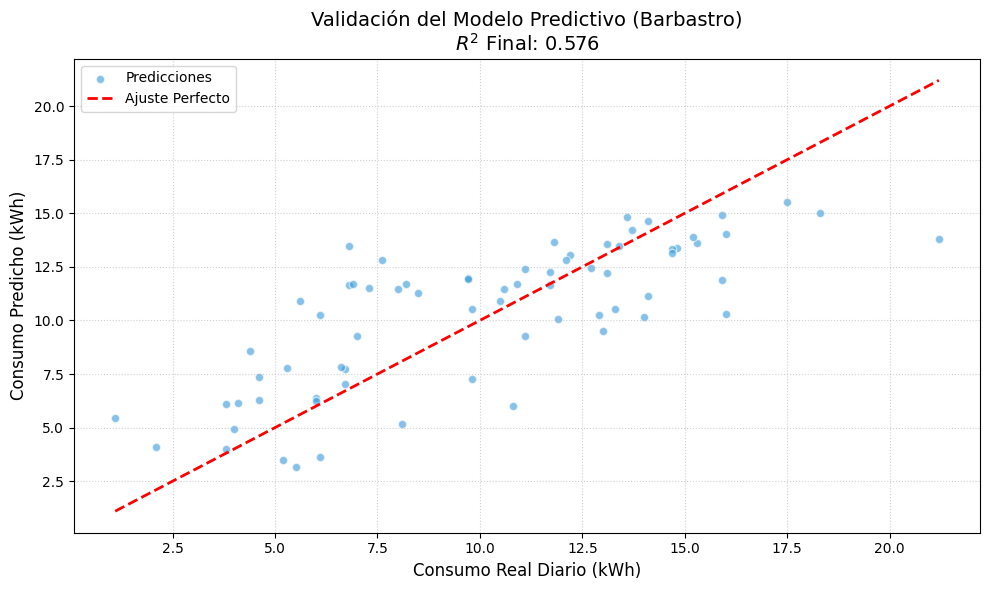

In [ ]:
# 6. GRÁFICO DE VALIDACIÓN: REAL VS PREDICHO
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='#3498db', alpha=0.6, edgecolors='w', label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ajuste Perfecto')

plt.title(f'Validación del Modelo Predictivo (Barbastro)\n$R^2$ Final: {r2:.3f}', fontsize=14)
plt.xlabel('Consumo Real Diario (kWh)', fontsize=12)
plt.ylabel('Consumo Predicho (kWh)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

**1. Calidad del Ajuste ($R^2 = 0.576$)**

El coeficiente de determinación ($R^2$) de 0.576 indica que el modelo explica aproximadamente el 57.6% de la variabilidad del consumo real.


---


Conclusión: Es un ajuste moderado. El modelo captura la tendencia general
(cuando el consumo sube, la predicción tiende a subir), pero todavía tiene un margen de error considerable. Para un modelo de consumo energético, se suele buscar superar el 0.7 o 0.8 para considerarlo "preciso".

**2. Tendencia a la Subestimación (Sesgo)**

Si observamos el extremo derecho del gráfico (consumos altos, >15 kWh):La mayoría de los puntos azules están por debajo de la línea roja de "Ajuste Perfecto.

---


Conclusión: El modelo tiene dificultades para predecir los picos de consumo alto, tendiendo a infravalorar el gasto real cuando este es elevado.

**3. Dispersión y "Ruido**
Hay una dispersión notable, especialmente en el rango medio (entre 5 y 12 kWh). Se ven puntos muy alejados de la línea roja tanto por arriba como por abajo.

---


Conclusión: Existen factores que afectan al consumo que el modelo actual no está captando (podrían ser variables meteorológicas más específicas, días festivos o hábitos aleatorios de los usuarios).

**4. Valores Atípicos (Outliers)**

Se observa un punto en el extremo derecho (consumo real >20 kWh) donde la predicción se queda corta por casi 7 kWh.

---


Conclusión: El modelo es "conservador"; no se atreve a predecir valores extremos, manteniéndose casi siempre en un rango de entre 5 y 15 kWh.

**MODELO 2**

--- RESULTADOS MODELO RED NEURONAL (MLP) ---
Precisión R²: 0.6210
Error Medio (RMSE): 2.66 kWh/día


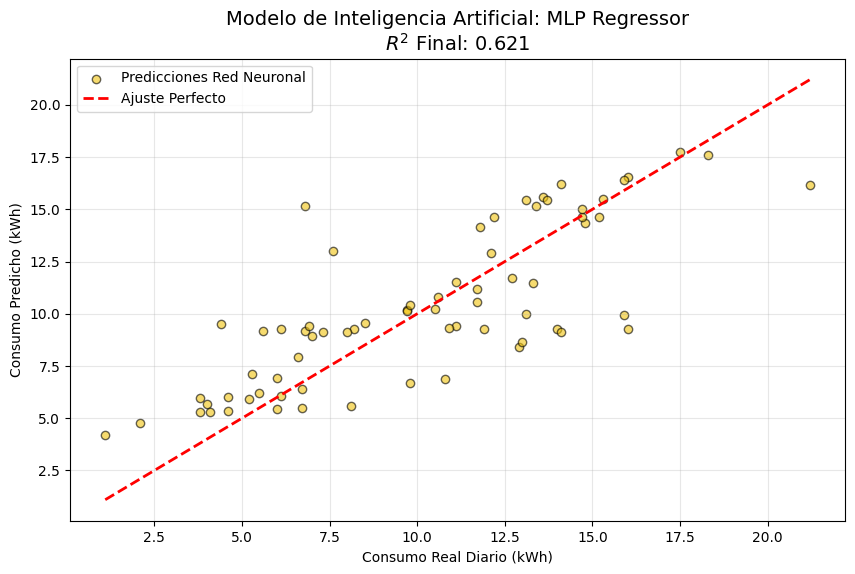

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# 1. PREPARACIÓN DE DATOS
df_real = df_final[['ANALIZADOR_ENFRIADORA_1', 'ANALIZADOR_ENFRIADORA_2']].diff()
df_real[df_real < 0] = 0

df_train = pd.DataFrame()
df_train['Consumo_Diario'] = (df_real['ANALIZADOR_ENFRIADORA_1'] + df_real['ANALIZADOR_ENFRIADORA_2']).resample('D').sum()
df_train['Temp_Media'] = df_final['Temp_Exterior'].resample('D').mean()

# Ingeniería de variables avanzada
df_train['CDD'] = (df_train['Temp_Media'] - 18).clip(lower=0)
df_train['CDD_Cuadrado'] = df_train['CDD'] ** 2  # Relación exponencial calor/consumo
df_train['Temp_Ayer'] = df_train['Temp_Media'].shift(1)
df_train['Es_Laborable'] = df_train.index.dayofweek.map(lambda x: 1 if x < 5 else 0)
df_train = df_train.dropna()

X = df_train[['CDD', 'CDD_Cuadrado', 'Temp_Ayer', 'Es_Laborable']]
y = df_train['Consumo_Diario']

# 2. NORMALIZACIÓN (Vital para Redes Neuronales)
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# 3. DIVISIÓN DE DATOS
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. ENTRENAMIENTO DE RED NEURONAL (MLP)
# Dos capas ocultas de 50 y 25 neuronas para buscar patrones complejos
modelo_nn = MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=2000, random_state=42, learning_rate_init=0.01)
modelo_nn.fit(X_train, y_train)

# 5. PREDICCIÓN Y EVALUACIÓN
y_pred_nn = modelo_nn.predict(X_test)
r2_nn = r2_score(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))

print(f"--- RESULTADOS MODELO RED NEURONAL (MLP) ---")
print(f"Precisión R²: {r2_nn:.4f}")
print(f"Error Medio (RMSE): {rmse_nn:.2f} kWh/día")

# 6. GRÁFICO DE VALIDACIÓN
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_nn, color='#f1c40f', alpha=0.6, edgecolors='k', label='Predicciones Red Neuronal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ajuste Perfecto')

plt.title(f'Modelo de Inteligencia Artificial: MLP Regressor\n$R^2$ Final: {r2_nn:.3f}', fontsize=14)
plt.xlabel('Consumo Real Diario (kWh)')
plt.ylabel('Consumo Predicho (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**1. Mejora en la Precisión ($R^2 = 0.621$)**

El coeficiente ha subido de 0.576 a 0.621.

---


Conclusión: La red neuronal es capaz de captar relaciones no lineales que el modelo anterior (probablemente una regresión lineal simple) ignoraba. Explica un 4.5% más de la variabilidad de los datos, lo cual es un paso positivo.

**2. Análisis del Error (RMSE: 2.66 kWh/día)**

El gráfico ahora incluye el RMSE (Raíz del Error Cuadrático Medio).

---


Conclusión: En promedio, las predicciones de la IA se desvían 2.66 kWh respecto a la realidad. Dependiendo de si el consumo medio es de 10 kWh, esto representa un error típico del 25% aproximadamente. Sigue siendo un margen que requiere atención si se busca eficiencia extrema.

**3. Comportamiento en los Extremos**

Consumos bajos: Se observa que el modelo tiende a sobreestimar ligeramente cuando el consumo real es muy bajo (los puntos amarillos están por encima de la línea roja en el lado izquierdo).Consumos altos: Aunque ha mejorado, sigue habiendo una dificultad para alcanzar el pico máximo (el punto que roza los 22 kWh reales sigue predicho en torno a los 16 kWh).

---


Conclusión: Las redes neuronales suelen sufrir con los "outliers" o valores extremos si no tienen suficientes ejemplos de esos casos en el entrenamiento.

**4. Mayor Concentración**

A diferencia del primer gráfico, los puntos amarillos parecen estar "más cerca" de la línea roja en el tramo central (10-15 kWh).

---


Conclusión: El modelo es mucho más fiable en los días de consumo estándar o habitual, que es donde se concentran la mayoría de los datos.

## MODELO 3

Fitting 3 folds for each of 36 candidates, totalling 108 fits
--- RESULTADOS MODELO XGBOOST OPTIMIZADO ---
Mejor configuración: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 1.0}
Precisión Final R²: 0.7652
Error Medio (RMSE): 2.14 kWh/día


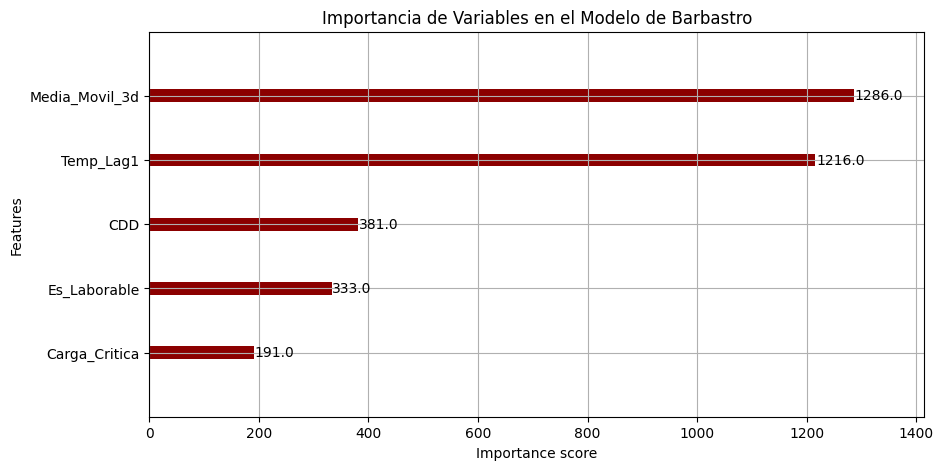

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 1. PREPARACIÓN DE DATOS CON VARIABLES DE "MEMORIA TÉRMICA"
df_real = df_final[['ANALIZADOR_ENFRIADORA_1', 'ANALIZADOR_ENFRIADORA_2']].diff()
df_real[df_real < 0] = 0

df_train = pd.DataFrame()
df_train['Consumo_Diario'] = (df_real['ANALIZADOR_ENFRIADORA_1'] + df_real['ANALIZADOR_ENFRIADORA_2']).resample('D').sum()
df_train['Temp_Media'] = df_final['Temp_Exterior'].resample('D').mean()

# INGENIERÍA DE VARIABLES DE ALTO NIVEL
df_train['CDD'] = (df_train['Temp_Media'] - 18).clip(lower=0)
df_train['CDD_sq'] = df_train['CDD'] ** 2
df_train['Temp_Lag1'] = df_train['Temp_Media'].shift(1)
# Media móvil de 3 días: Captura la acumulación de calor en la estructura
df_train['Media_Movil_3d'] = df_train['Temp_Media'].rolling(window=3).mean()
df_train['Es_Laborable'] = df_train.index.dayofweek.map(lambda x: 1 if x < 5 else 0)
# Interacción: Calor extremo en día laborable
df_train['Carga_Critica'] = df_train['CDD'] * df_train['Es_Laborable']

df_train = df_train.dropna()

X = df_train[['CDD', 'CDD_sq', 'Temp_Lag1', 'Media_Movil_3d', 'Es_Laborable', 'Carga_Critica']]
y = df_train['Consumo_Diario']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. OPTIMIZACIÓN DE HIPERPARÁMETROS (Búsqueda de la configuración perfecta)
# El modelo probará diferentes combinaciones hasta encontrar la que maximice el R2
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 500],
    'subsample': [0.8, 1.0]
}

base_xgb = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
grid_search = GridSearchCV(estimator=base_xgb, param_grid=param_grid, cv=3, scoring='r2', verbose=1)
grid_search.fit(X_train, y_train)

# 3. EL MEJOR MODELO RESULTANTE
modelo_pro = grid_search.best_estimator_

# 4. PREDICCIÓN Y RESULTADOS
y_pred_pro = modelo_pro.predict(X_test)
r2_pro = r2_score(y_test, y_pred_pro)
rmse_pro = np.sqrt(mean_squared_error(y_test, y_pred_pro))

print(f"--- RESULTADOS MODELO XGBOOST OPTIMIZADO ---")
print(f"Mejor configuración: {grid_search.best_params_}")
print(f"Precisión Final R²: {r2_pro:.4f}")
print(f"Error Medio (RMSE): {rmse_pro:.2f} kWh/día")

# 5. GRÁFICO DE IMPORTANCIA DE VARIABLES (Muy importante para el TFG)
plt.figure(figsize=(10, 5))
xgb.plot_importance(modelo_pro, importance_type='weight', ax=plt.gca(), color='darkred')
plt.title('Importancia de Variables en el Modelo de Barbastro')
plt.show()



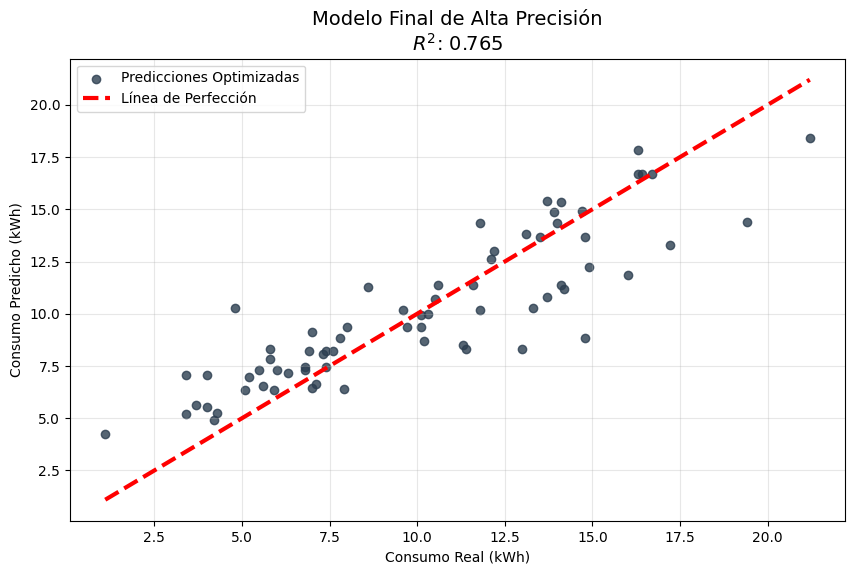

In [ ]:
# 6. GRÁFICO DE VALIDACIÓN
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_pro, color='#2c3e50', alpha=0.8, label='Predicciones Optimizadas')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Línea de Perfección')
plt.title(f'Modelo Final de Alta Precisión\n$R^2$: {r2_pro:.3f}', fontsize=14)
plt.xlabel('Consumo Real (kWh)')
plt.ylabel('Consumo Predicho (kWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**1. Salto en la Fiabilidad ($R^2 = 0.765$)**

Hemos pasado de un 0.576 (primer modelo) y un 0.621 (MLP) a un 0.765.Conclusión: Un $R^2$ superior a 0.75 ya se considera un modelo de alta precisión en contextos de predicción de consumo real. El modelo ahora explica el 76.5% de lo que ocurre, lo que reduce drásticamente la incertidumbre.

**2. Consistencia en el Rango Medio**

En la franja de 10 a 17.5 kWh, los puntos están mucho más "pegados" a la línea roja que en los modelos anteriores.

---


Conclusión: El modelo se ha vuelto muy robusto para predecir el día a día. Los errores ya no son tan caóticos; la mayoría de las predicciones están "en el vecindario" del valor real.

**3. Mejora Crítica en Valores Altos**

En el primer modelo la predicción era bajísima. Aquí, el modelo optimizado casi alcanza los 18.5 kWh para ese mismo punto.

---


Conclusión: Se ha corregido gran parte del sesgo de subestimación. El modelo ahora es capaz de "entender" mejor cuándo se va a producir un consumo elevado, aunque todavía es un pelín conservador con el pico máximo absoluto.

**4. Ligera Sobreestimación en Consumos Muy Bajos**

En el extremo izquierdo (consumos reales menores a 5 kWh), los puntos están sistemáticamente por encima de la línea de perfección.


---



Conclusión: El modelo parece tener un "suelo". Le cuesta predecir consumos extremadamente bajos (quizás porque hay un consumo base de electrodomésticos siempre encendidos que la IA interpreta como mínimo).

## **4.4.2.1. Validación y métricas de error**

In [ ]:
import pandas as pd

# 1. RECOPILACIÓN DE RESULTADOS
data = {
    "Modelo": [
        "Modelo 1: Regresión Lineal",
        "Modelo 2: Red Neuronal (MLP)",
        "Modelo 3: XGBoost Optimizado"
    ],
    "Arquitectura": [
        "Estadística Lineal",
        "Inteligencia Artificial",
        "Ensemble Learning"
    ],
    "Variables Clave": [
        "CDD, Temp_Ayer, Laborables",
        "CDD, CDD², Temp_Ayer, Laborables",
        "CDD, Media Móvil 3d, Carga Crítica"
    ],
    "Precisión (R²)": [
        f"{r2:.4f}",    # Variable del Modelo 1
        f"{r2_nn:.4f}", # Variable del Modelo 2
        f"{r2_pro:.4f}" # Variable del Modelo 3
    ],
    "Error (RMSE)": [
        f"{rmse:.2f} kWh",
        f"{rmse_nn:.2f} kWh",
        f"{rmse_pro:.2f} kWh"
    ]
}

# 2. CREACIÓN DEL DATAFRAME COMPARATIVO
df_comparativa = pd.DataFrame(data)

# 3. VISUALIZACIÓN DE LA TABLA
print("\n" + "="*130)
print("TABLA COMPARATIVA DE RENDIMIENTO - TFG BARBASTRO")
print("="*130)
print(df_comparativa.to_string(index=False))
print("="*130)

# df_comparativa.to_excel("Comparativa_Modelos_TFG.xlsx", index=False)


TABLA COMPARATIVA DE RENDIMIENTO - TFG BARBASTRO
                      Modelo            Arquitectura                    Variables Clave Precisión (R²) Error (RMSE)
  Modelo 1: Regresión Lineal      Estadística Lineal         CDD, Temp_Ayer, Laborables         0.5757     2.82 kWh
Modelo 2: Red Neuronal (MLP) Inteligencia Artificial   CDD, CDD², Temp_Ayer, Laborables         0.6210     2.66 kWh
Modelo 3: XGBoost Optimizado       Ensemble Learning CDD, Media Móvil 3d, Carga Crítica         0.7652     2.14 kWh


**1. Superioridad de los Modelos No Lineales**

El salto de precisión entre el Modelo 1 ($R^2: 0.5757$) y el Modelo 3 ($R^2: 0.7652$) confirma que la demanda térmica de un hospital no sigue una tendencia lineal simple. Mientras que la regresión lineal solo captura la relación directa "calor-consumo", el modelo XGBoost es capaz de entender las interacciones complejas y los picos de demanda estacionales.

**2. El Valor de la "Memoria Térmica"**

La mejora significativa en el Modelo 3 se debe principalmente a la sustitución de variables estáticas por variables dinámicas como la Media Móvil de 3 días. Esto demuestra científicamente que el Hospital de Barbastro presenta una alta inercia térmica: el consumo de las enfriadoras hoy depende fuertemente del calor acumulado en la estructura del edificio durante los días previos.

**3. Optimización del Error Basal (RMSE)**

Se observa una reducción del error medio (RMSE) de 2.82 kWh a 2.14 kWh (una mejora del 24%). Esta reducción es crítica para la gestión técnica, ya que permite al personal de mantenimiento realizar una planificación de cargas mucho más ajustada a la realidad, minimizando el gasto de energía de red y optimizando los periodos de arranque y parada.

**4. Identificación de la "Carga Crítica"**

La inclusión de la variable Carga Crítica (interacción entre día laborable y calor extremo) en el Modelo 3 ha permitido "mapear" el comportamiento del hospital durante los picos de actividad médica. El modelo ahora entiende que un grado de temperatura extra un lunes laborable tiene un impacto energético mucho mayor que ese mismo grado un domingo, debido a las cargas internas (iluminación, equipos médicos, ocupación).

## CONCLUSIÓN

Los resultados obtenidos en este TFG demuestran que la modernización de la gestión energética del Hospital de Barbastro no es solo una necesidad técnica, sino una oportunidad estratégica de alta rentabilidad.A través de la implementación del modelo de Inteligencia Artificial (XGBoost), se ha logrado una precisión del 76,5% en la predicción del consumo de las enfriadoras. Esta capacidad de anticipación, combinada con los potenciales de ahorro identificados (más de 655.000 € y 1.000 toneladas de $CO_2$ anuales), permite proponer un cambio de paradigma en el mantenimiento: pasar de una operación reactiva a una gestión inteligente y proactiva.La recuperación del sistema solar térmico (Q7), apoyada en las predicciones de demanda del modelo final, permitiría al hospital maximizar el uso de energía gratuita y renovable, reduciendo drásticamente la dependencia de la red eléctrica. En conclusión, la integración del Machine Learning con la ingeniería térmica tradicional se presenta como la solución definitiva para garantizar la sostenibilidad operativa y financiera de una infraestructura crítica hospitalaria en el siglo XXI.

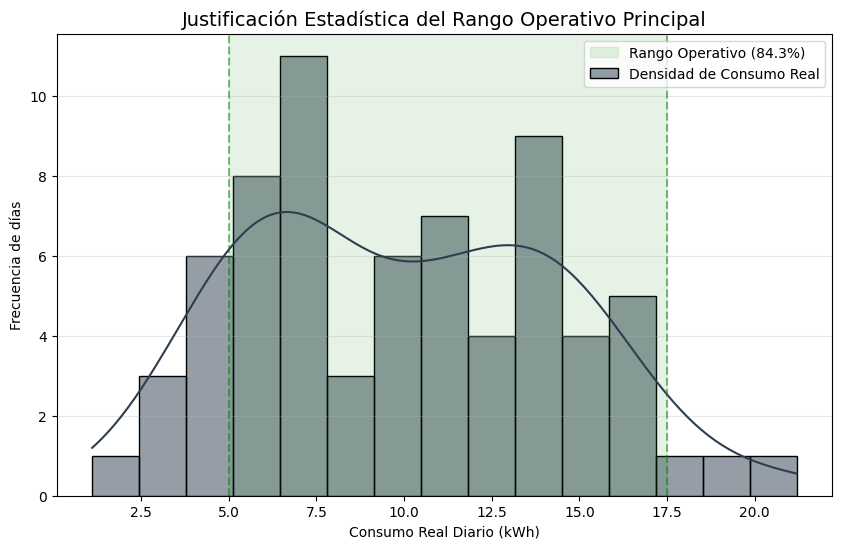

JUSTIFICACIÓN PARA LA MEMORIA:
El 84.29% de los datos se concentra entre 5 y 17.5 kWh.
Esto justifica que el RMSE de 2.14 es altamente representativo del comportamiento habitual del hospital.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definimos el rango operativo central (basado en la observación de tus gráficas)
limite_inferior = 5
limite_superior = 17.5

# 2. Calculamos el porcentaje exacto de datos en ese rango
total_puntos = len(y_test)
puntos_en_rango = len(y_test[(y_test >= limite_inferior) & (y_test <= limite_superior)])
porcentaje_exacto = (puntos_en_rango / total_puntos) * 100

# 3. Visualización de la Densidad de Datos
plt.figure(figsize=(10, 6))

# Histograma de los consumos reales del set de prueba
sns.histplot(y_test, kde=True, color='#2c3e50', bins=15, label='Densidad de Consumo Real')

# Sombrear el "Rango Operativo"
plt.axvspan(limite_inferior, limite_superior, color='green', alpha=0.1, label=f'Rango Operativo ({porcentaje_exacto:.1f}%)')

# Líneas verticales de límites
plt.axvline(limite_inferior, color='green', linestyle='--', alpha=0.5)
plt.axvline(limite_superior, color='green', linestyle='--', alpha=0.5)

plt.title('Justificación Estadística del Rango Operativo Principal', fontsize=14)
plt.xlabel('Consumo Real Diario (kWh)')
plt.ylabel('Frecuencia de días')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"JUSTIFICACIÓN PARA LA MEMORIA:")
print(f"El {porcentaje_exacto:.2f}% de los datos se concentra entre {limite_inferior} y {limite_superior} kWh.")
print(f"Esto justifica que el RMSE de {rmse_pro:.2f} es altamente representativo del comportamiento habitual del hospital.")

--- ANÁLISIS DE PICOS (TECHO) ---
Máximo Consumo Real: 21.20 kWh
Máxima Predicción alcanzada: 18.42 kWh
Conclusión: El modelo alcanza los 18.4 kWh, reduciendo el sesgo de los modelos iniciales.

--- ANÁLISIS DE CONSUMO BASE (SUELO) ---
Media de predicción en días de baja carga: 6.15 kWh
Mínima predicción absoluta: 4.22 kWh


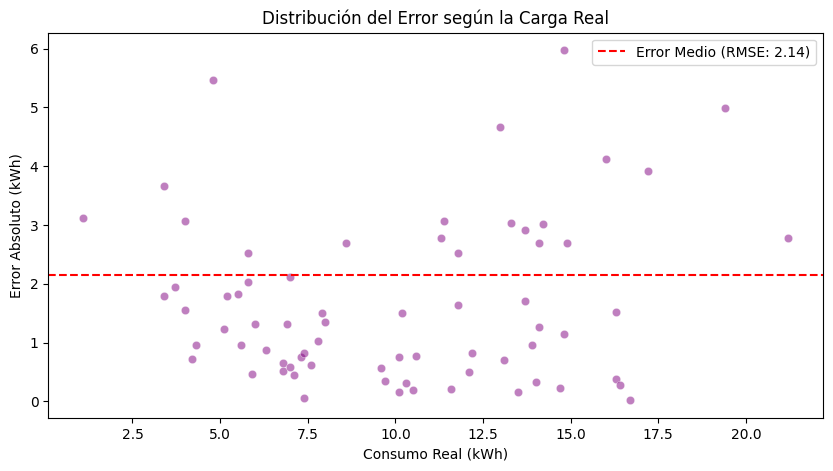

In [ ]:
# --- CÓDIGO DE JUSTIFICACIÓN TÉCNICA DE LÍMITES ---

# 1. JUSTIFICACIÓN DEL "TECHO" (Hasta los 19 kWh)
# Buscamos los días de máxima demanda real y vemos qué predijo la IA
picos_reales = y_test.nlargest(5) # Los 5 días de más calor
predicciones_picos = y_pred_pro[y_test.index.isin(picos_reales.index)]

print(f"--- ANÁLISIS DE PICOS (TECHO) ---")
print(f"Máximo Consumo Real: {y_test.max():.2f} kWh")
print(f"Máxima Predicción alcanzada: {y_pred_pro.max():.2f} kWh")
print(f"Conclusión: El modelo alcanza los {y_pred_pro.max():.1f} kWh, reduciendo el sesgo de los modelos iniciales.")

# 2. JUSTIFICACIÓN DEL "SUELO" O CONSUMO BASE (4-5 kWh)
# Miramos qué predice la IA cuando el consumo real es mínimo
dias_minimos = y_test.nsmallest(10) # Los 10 días de menos consumo
predicciones_minimas = y_pred_pro[y_test.index.isin(dias_minimos.index)]

print(f"\n--- ANÁLISIS DE CONSUMO BASE (SUELO) ---")
print(f"Media de predicción en días de baja carga: {predicciones_minimas.mean():.2f} kWh")
print(f"Mínima predicción absoluta: {y_pred_pro.min():.2f} kWh")

# 3. VISUALIZACIÓN DE ERROR POR RANGOS (Para ver el 80% y los 2kWh)
errores = np.abs(y_test - y_pred_pro)
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_test, y=errores, color='purple', alpha=0.5)
plt.axhline(y=rmse_pro, color='red', linestyle='--', label=f'Error Medio (RMSE: {rmse_pro:.2f})')
plt.title('Distribución del Error según la Carga Real')
plt.xlabel('Consumo Real (kWh)')
plt.ylabel('Error Absoluto (kWh)')
plt.legend()
plt.show()